<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 - Aprendizaje no supervisado
## Ejercicio 1 — Triaje oncológico asistido por algoritmos

**Dataset:** `datos_pacientes.csv` y `datos_pacientes_diagnosticados.csv`  
**Grupo:** 8 | **Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustín | **Año:** 2026

> **Contexto:** Un hospital regional puede diagnosticar solo 2 pacientes/día. Con 560 en cola, el último esperaría 280 días. El objetivo es ordenar la cola priorizando los de mayor riesgo de malignidad, usando únicamente los estudios preliminares (sin diagnóstico previo).


---
## 0. Configuración del entorno

In [1]:
# Instalar dependencias no estándar
import subprocess, sys
for pkg in ["umap-learn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)
print("Dependencias listas.")

Dependencias listas.


In [2]:
import warnings, sys, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, silhouette_samples,
    calinski_harabasz_score
)
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.pipeline import Pipeline
import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
print("Entorno listo.")

Entorno listo.


In [3]:
# Descarga del dataset desde Google Drive
import os
if not os.path.exists("datos_pacientes.csv"):
    os.system('wget -q --no-check-certificate "https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t" -O datos_pacientes.zip')
    os.system('unzip -o datos_pacientes.zip')
    print("Archivos descargados.")
else:
    print("Archivos ya presentes.")

Archivos descargados.


---
## 1. Carga y Análisis Exploratorio de Datos (EDA)

In [4]:
df_pac = pd.read_csv("datos_pacientes.csv")
df_diag = pd.read_csv("datos_pacientes_diagnosticados.csv")

FEATURE_COLS = [c for c in df_pac.columns if c != "id"]
print(f"datos_pacientes:          {df_pac.shape}  — {len(FEATURE_COLS)} features, sin etiqueta")
print(f"datos_pacientes_diag:     {df_diag.shape}  — incluye columna 'diagnosis'")
print(f"\nDistribución de diagnósticos:")
print(df_diag["diagnosis"].value_counts())
df_pac.head(3)

datos_pacientes:          (560, 31)  — 30 features, sin etiqueta
datos_pacientes_diag:     (9, 32)  — incluye columna 'diagnosis'

Distribución de diagnósticos:
diagnosis
B    6
M    3
Name: count, dtype: int64


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,915940,14.58,13.66,94.29,658.8,0.09832,0.08918,0.08222,0.043490,0.1739,...,16.76,17.24,108.50,862.0,0.1223,0.1928,0.24920,0.09186,0.2626,0.07048
1,893988,11.54,10.72,73.73,409.1,0.08597,0.05969,0.01367,0.008907,0.1833,...,12.34,12.87,81.23,467.8,0.1092,0.1626,0.08324,0.04715,0.3390,0.07434
2,8910251,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.026420,0.1922,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587


In [5]:
# Verificación de calidad de datos
print("=== CALIDAD DE DATOS ===")
print(f"Nulos en datos_pacientes:        {df_pac.isnull().sum().sum()}")
print(f"Nulos en datos_diagnosticados:   {df_diag.isnull().sum().sum()}")
print(f"Duplicados en datos_pacientes:   {df_pac.duplicated().sum()}")

print("\n=== ESTADÍSTICAS DESCRIPTIVAS (datos_pacientes) ===")
df_pac[FEATURE_COLS].describe().T[["mean","std","min","max"]].style.background_gradient(cmap="Blues", axis=0)

=== CALIDAD DE DATOS ===
Nulos en datos_pacientes:        0
Nulos en datos_diagnosticados:   0
Duplicados en datos_pacientes:   0

=== ESTADÍSTICAS DESCRIPTIVAS (datos_pacientes) ===


,mean,std,min,max
radius_mean,14.139805,3.524507,6.981000,28.110000
texture_mean,19.343804,4.288002,9.710000,39.280000
perimeter_mean,92.048107,24.307755,43.790000,188.500000
area_mean,656.062500,352.594258,143.500000,2501.000000
smoothness_mean,0.096239,0.014122,0.052630,0.163400
compactness_mean,0.104211,0.052825,0.019380,0.345400
concavity_mean,0.088747,0.079782,0.000000,0.426800
concave points_mean,0.048890,0.038822,0.000000,0.201200
symmetry_mean,0.181178,0.027575,0.106000,0.304000
fractal_dimension_mean,0.062750,0.007071,0.049960,0.097440


### 1.1 Distribución de las 30 features

Visualizamos histogramas para detectar asimetrías, escalas y posibles outliers. Muchas features de biopsias tienen distribuciones sesgadas a la derecha (valores extremos en tumores malignos).


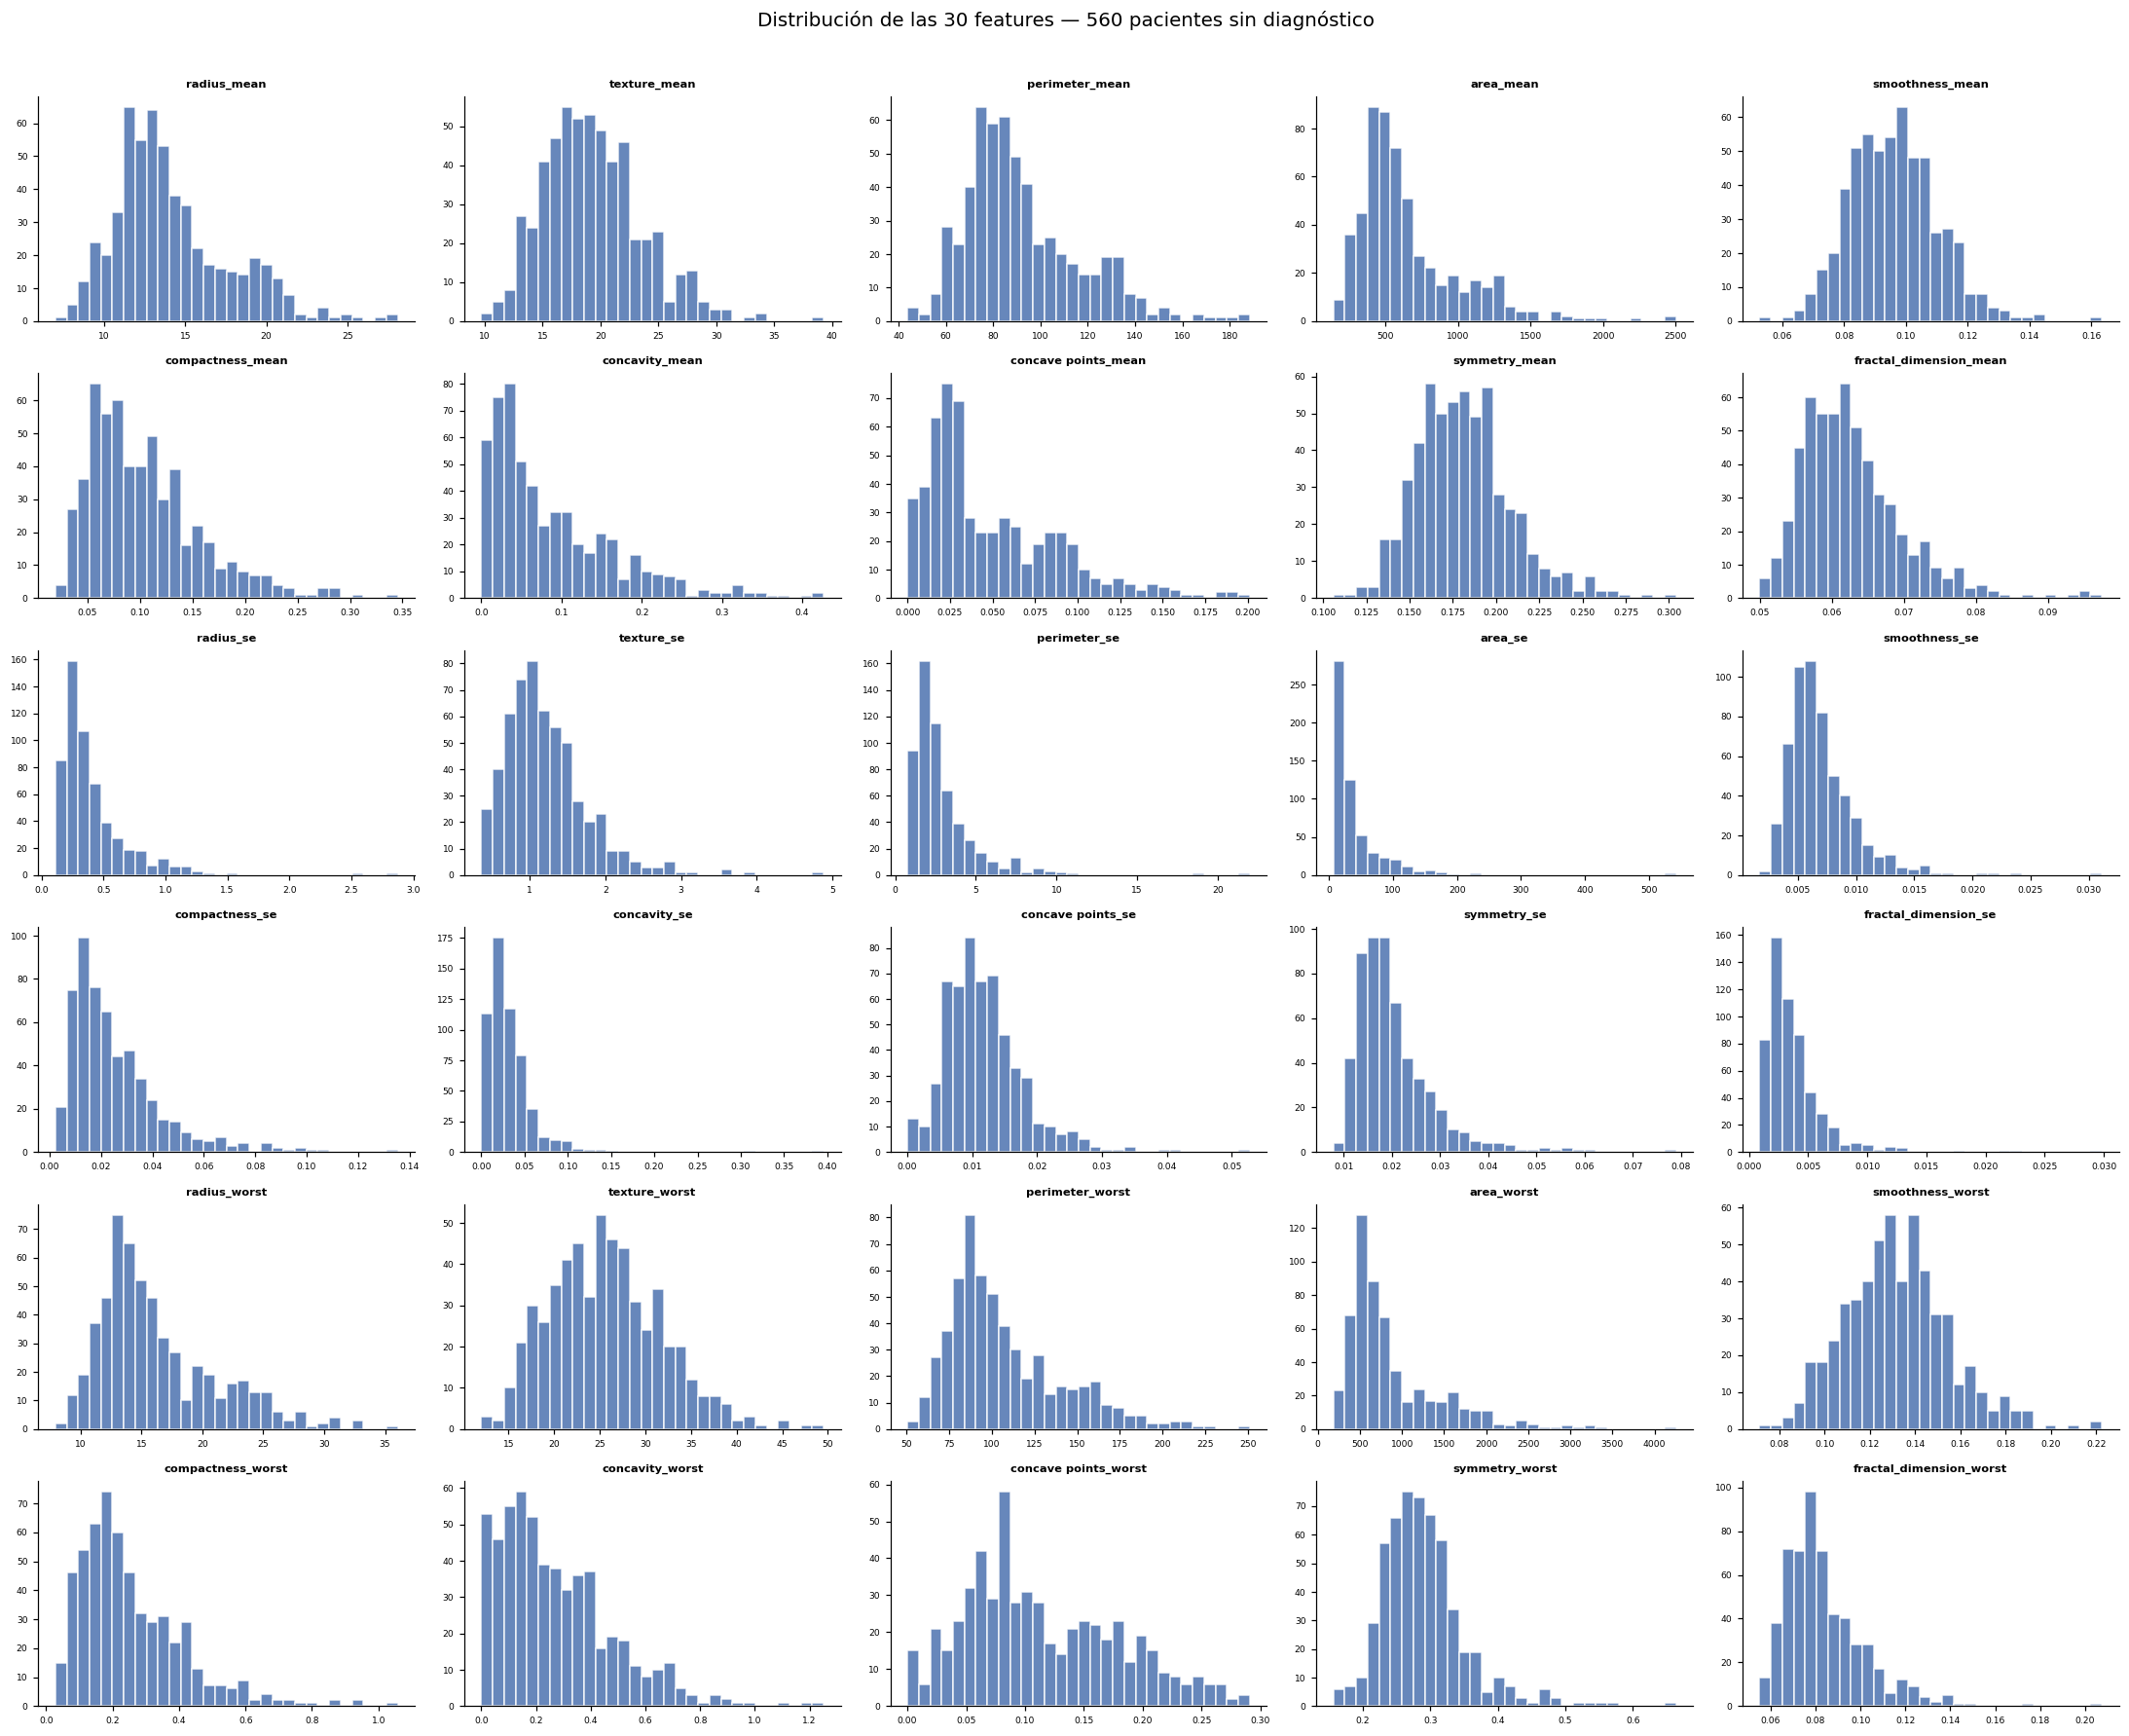

In [6]:
fig, axes = plt.subplots(6, 5, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(df_pac[col], bins=30, color="#4C72B0", edgecolor="white", lw=0.5, alpha=0.85)
    axes[i].set_title(col, fontsize=7.5, fontweight="bold")
    axes[i].tick_params(labelsize=6)
plt.suptitle("Distribución de las 30 features — 560 pacientes sin diagnóstico", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.2 Comparación de distribuciones: diagnosticados vs sin diagnóstico

Aunque la mayoría de los 560 no tienen diagnóstico, los 9 diagnosticados nos permiten ver si los grupos M/B se diferencian visualmente en cada feature.


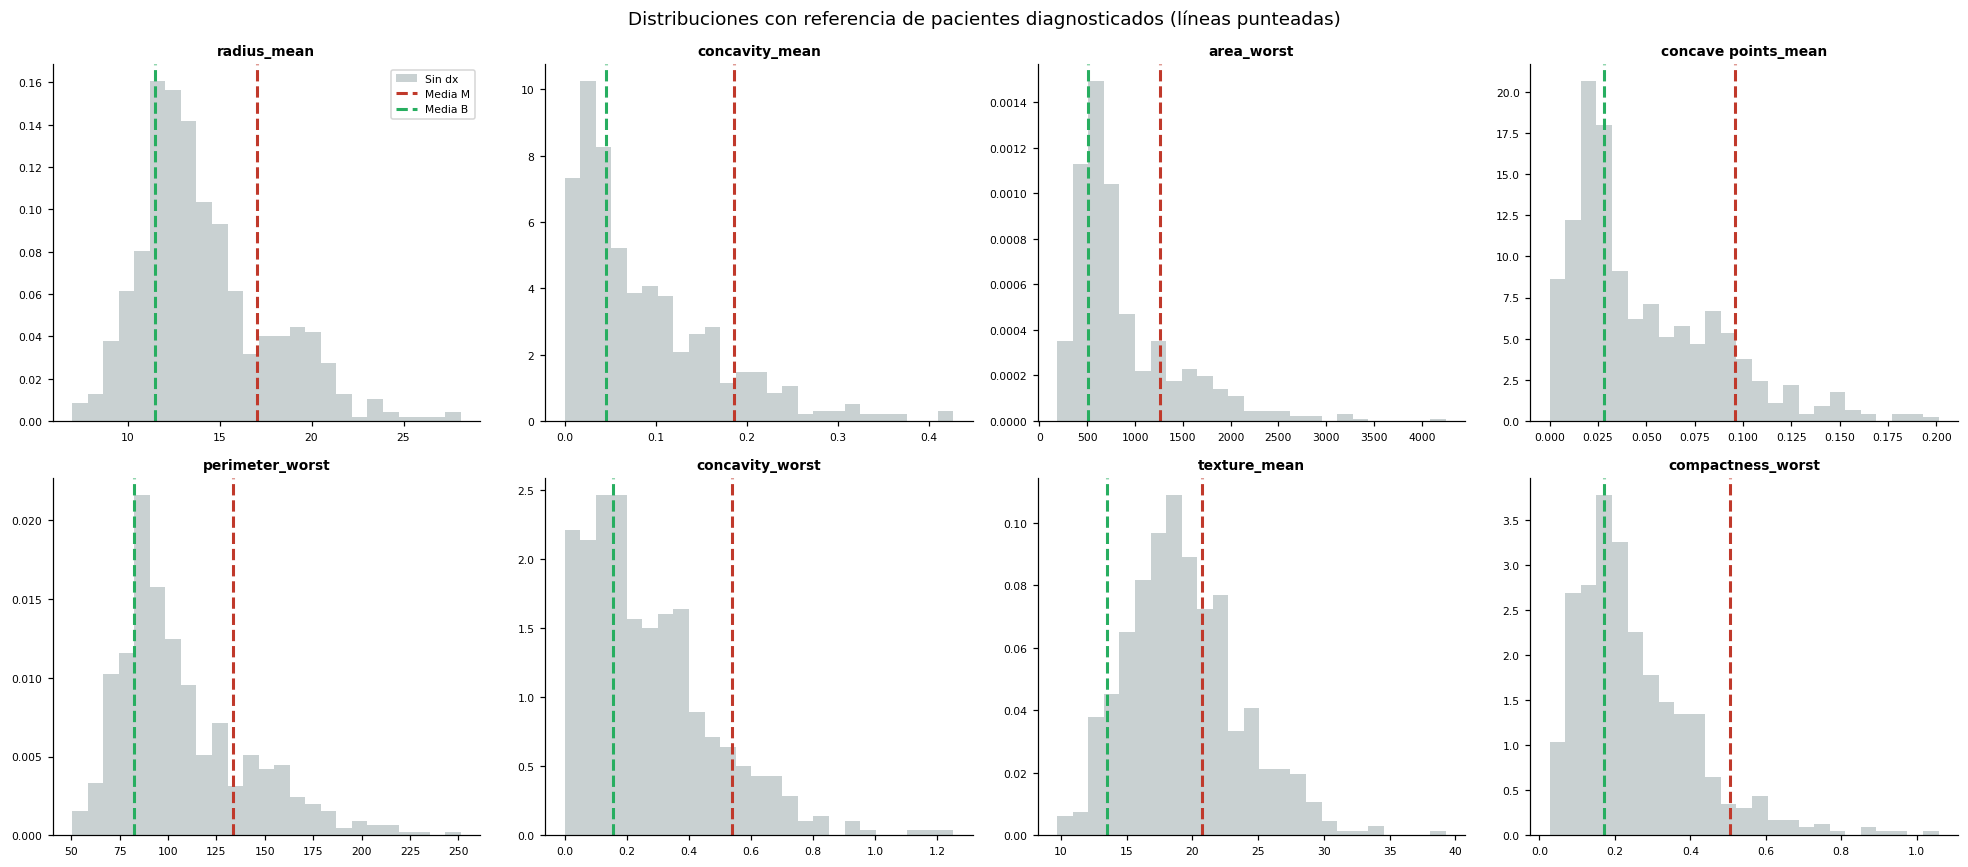

In [7]:
# Superposición de distribuciones: sin diagnóstico vs M vs B
top_feats = ["radius_mean", "concavity_mean", "area_worst", "concave points_mean",
             "perimeter_worst", "concavity_worst", "texture_mean", "compactness_worst"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
diag_M = df_diag[df_diag["diagnosis"] == "M"]
diag_B = df_diag[df_diag["diagnosis"] == "B"]

for i, feat in enumerate(top_feats):
    ax = axes[i]
    ax.hist(df_pac[feat], bins=25, color="#95A5A6", alpha=0.5, label="Sin dx", density=True)
    if len(diag_M) > 0:
        ax.axvline(diag_M[feat].mean(), color="#C0392B", lw=2, linestyle="--", label="Media M")
    if len(diag_B) > 0:
        ax.axvline(diag_B[feat].mean(), color="#27AE60", lw=2, linestyle="--", label="Media B")
    ax.set_title(feat, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Distribuciones con referencia de pacientes diagnosticados (líneas punteadas)", fontsize=12)
plt.tight_layout()
plt.show()

### 1.3 Matriz de correlación

Con 30 features, esperamos alta redundancia (radius, perimeter y area son geométricamente dependientes). Las features altamente correlacionadas no aportan información independiente al clustering.


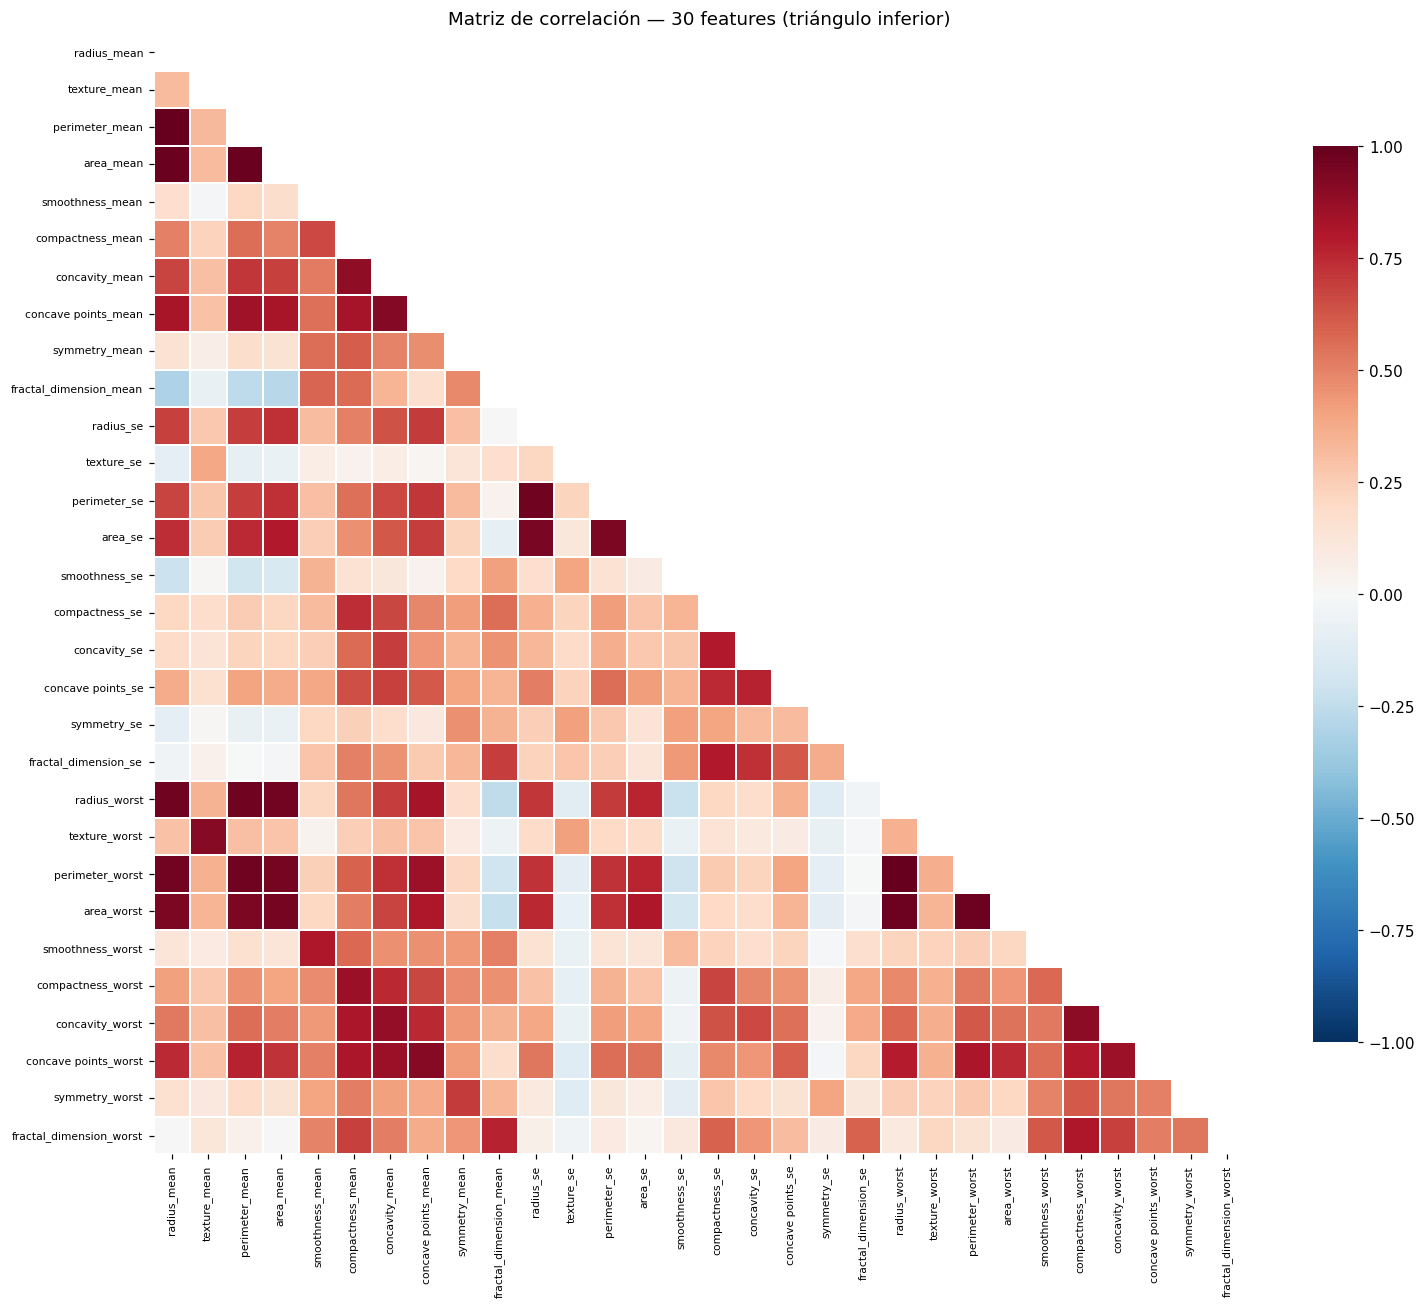

Pares de features con correlación > 0.90: 21
  radius_mean ↔ perimeter_mean: r=0.998
  radius_worst ↔ perimeter_worst: r=0.994
  radius_mean ↔ area_mean: r=0.987
  perimeter_mean ↔ area_mean: r=0.987
  radius_worst ↔ area_worst: r=0.984
  perimeter_worst ↔ area_worst: r=0.978
  radius_se ↔ perimeter_se: r=0.973
  perimeter_mean ↔ perimeter_worst: r=0.970
  perimeter_mean ↔ radius_worst: r=0.969
  radius_mean ↔ radius_worst: r=0.969


In [8]:
corr = df_pac[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.3, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de correlación — 30 features (triángulo inferior)", fontsize=12)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

# Features con alta correlación (> 0.9)
high_corr = []
corr_vals = corr.abs()
for i in range(len(FEATURE_COLS)):
    for j in range(i+1, len(FEATURE_COLS)):
        if corr_vals.iloc[i, j] > 0.90:
            high_corr.append((FEATURE_COLS[i], FEATURE_COLS[j], corr_vals.iloc[i, j]))

print(f"Pares de features con correlación > 0.90: {len(high_corr)}")
for f1, f2, r in sorted(high_corr, key=lambda x: -x[2])[:10]:
    print(f"  {f1} ↔ {f2}: r={r:.3f}")

**Hallazgo clave:** Existe fuerte multicolinealidad entre `radius`, `perimeter` y `area` (correlación > 0.98), y entre sus versiones `_mean`, `_se` y `_worst`. Esto justifica la reducción de dimensionalidad antes del clustering.


### 1.4 Detección de outliers (IQR)


In [9]:
# Conteo de outliers por feature usando método IQR
Q1 = df_pac[FEATURE_COLS].quantile(0.25)
Q3 = df_pac[FEATURE_COLS].quantile(0.75)
IQR = Q3 - Q1
outliers_count = ((df_pac[FEATURE_COLS] < (Q1 - 1.5*IQR)) | (df_pac[FEATURE_COLS] > (Q3 + 1.5*IQR))).sum()
outliers_pct = (outliers_count / len(df_pac) * 100).round(1)

df_out = pd.DataFrame({"Outliers": outliers_count, "Porcentaje (%)": outliers_pct})
df_out_sorted = df_out.sort_values("Porcentaje (%)", ascending=False).head(15)
print("Top 15 features con más outliers:")
print(df_out_sorted.to_string())

Top 15 features con más outliers:
                         Outliers  Porcentaje (%)
area_se                        64            11.4
perimeter_se                   38             6.8
radius_se                      37             6.6
area_worst                     34             6.1
smoothness_se                  28             5.0
compactness_se                 28             5.0
fractal_dimension_se           27             4.8
symmetry_se                    26             4.6
area_mean                      25             4.5
symmetry_worst                 23             4.1
fractal_dimension_worst        22             3.9
concavity_se                   22             3.9
texture_se                     19             3.4
concave points_se              19             3.4
concavity_mean                 18             3.2


---
## 2. Preprocesamiento y Pipeline

**Decisiones tomadas:**
- Se eliminó la columna `id` (identificador sin valor predictivo).
- Se aplicó `StandardScaler` para estandarizar todas las features a media 0 y desviación estándar 1. Esto es **obligatorio** antes del clustering con K-Means y distancias euclidianas: sin escalado, features con mayor rango (como `area_mean`) dominarían la distancia.
- No se imputaron valores ya que no hay nulos.


In [10]:
# Pipeline de preprocesamiento
X_raw = df_pac[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Dataset de diagnosticados (sin la columna diagnosis ni id)
X_diag_raw = df_diag[FEATURE_COLS].values
X_diag_scaled = scaler.transform(X_diag_raw)   # mismo scaler, solo transform
y_diag = df_diag["diagnosis"].values

print(f"X_scaled shape:      {X_scaled.shape}")
print(f"X_diag_scaled shape: {X_diag_scaled.shape}")
print(f"Etiquetas diag: {dict(zip(*np.unique(y_diag, return_counts=True)))}")

X_scaled shape:      (560, 30)
X_diag_scaled shape: (9, 30)
Etiquetas diag: {'B': np.int64(6), 'M': np.int64(3)}


---
## 3. Reducción de Dimensionalidad: PCA, t-SNE y UMAP

>Vamos a encontrar estructura en datos de 30 dimensiones con las herramientas de reducción de dimensionalidad PCA, t-SNE y UMAP


Componentes para explicar 90% de varianza: 7
PC1 explica: 44.3%
PC2 explica: 19.0%
PC1+PC2:     63.3%


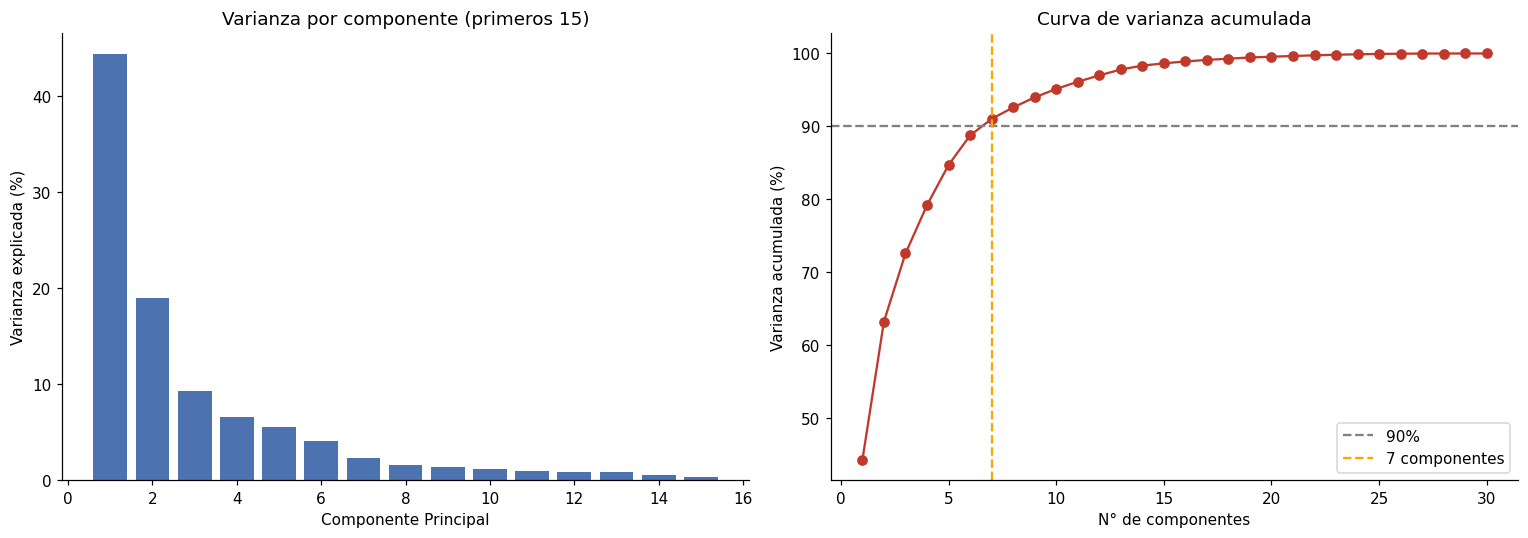

In [11]:
# ── PCA ─────────────────────────────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)

# ¿Cuántos componentes explican el 90% de la varianza?
n90 = np.searchsorted(varianza_acum, 0.90) + 1
print(f"Componentes para explicar 90% de varianza: {n90}")
print(f"PC1 explica: {pca_full.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explica: {pca_full.explained_variance_ratio_[1]*100:.1f}%")
print(f"PC1+PC2:     {sum(pca_full.explained_variance_ratio_[:2])*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 16), pca_full.explained_variance_ratio_[:15]*100, color="#4C72B0")
axes[0].set_xlabel("Componente Principal"); axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Varianza por componente (primeros 15)")

axes[1].plot(range(1, 31), varianza_acum*100, "o-", color="#C0392B")
axes[1].axhline(90, ls="--", color="gray", label="90%")
axes[1].axvline(n90, ls="--", color="orange", label=f"{n90} componentes")
axes[1].set_xlabel("N° de componentes"); axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Curva de varianza acumulada"); axes[1].legend()
plt.tight_layout(); plt.show()

In [12]:
# Proyección 2D para visualización
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)
X_diag_pca = pca_2d.transform(X_diag_scaled)

tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
X_all_tsne = tsne.fit_transform(np.vstack([X_scaled, X_diag_scaled]))
X_tsne = X_all_tsne[:len(X_scaled)]
X_diag_tsne = X_all_tsne[len(X_scaled):]

reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    random_state=RANDOM_STATE, n_jobs=1)
X_all_umap = reducer.fit_transform(np.vstack([X_scaled, X_diag_scaled]))
X_umap = X_all_umap[:len(X_scaled)]
X_diag_umap = X_all_umap[len(X_scaled):]

print("Proyecciones 2D calculadas: PCA, t-SNE, UMAP.")

Proyecciones 2D calculadas: PCA, t-SNE, UMAP.


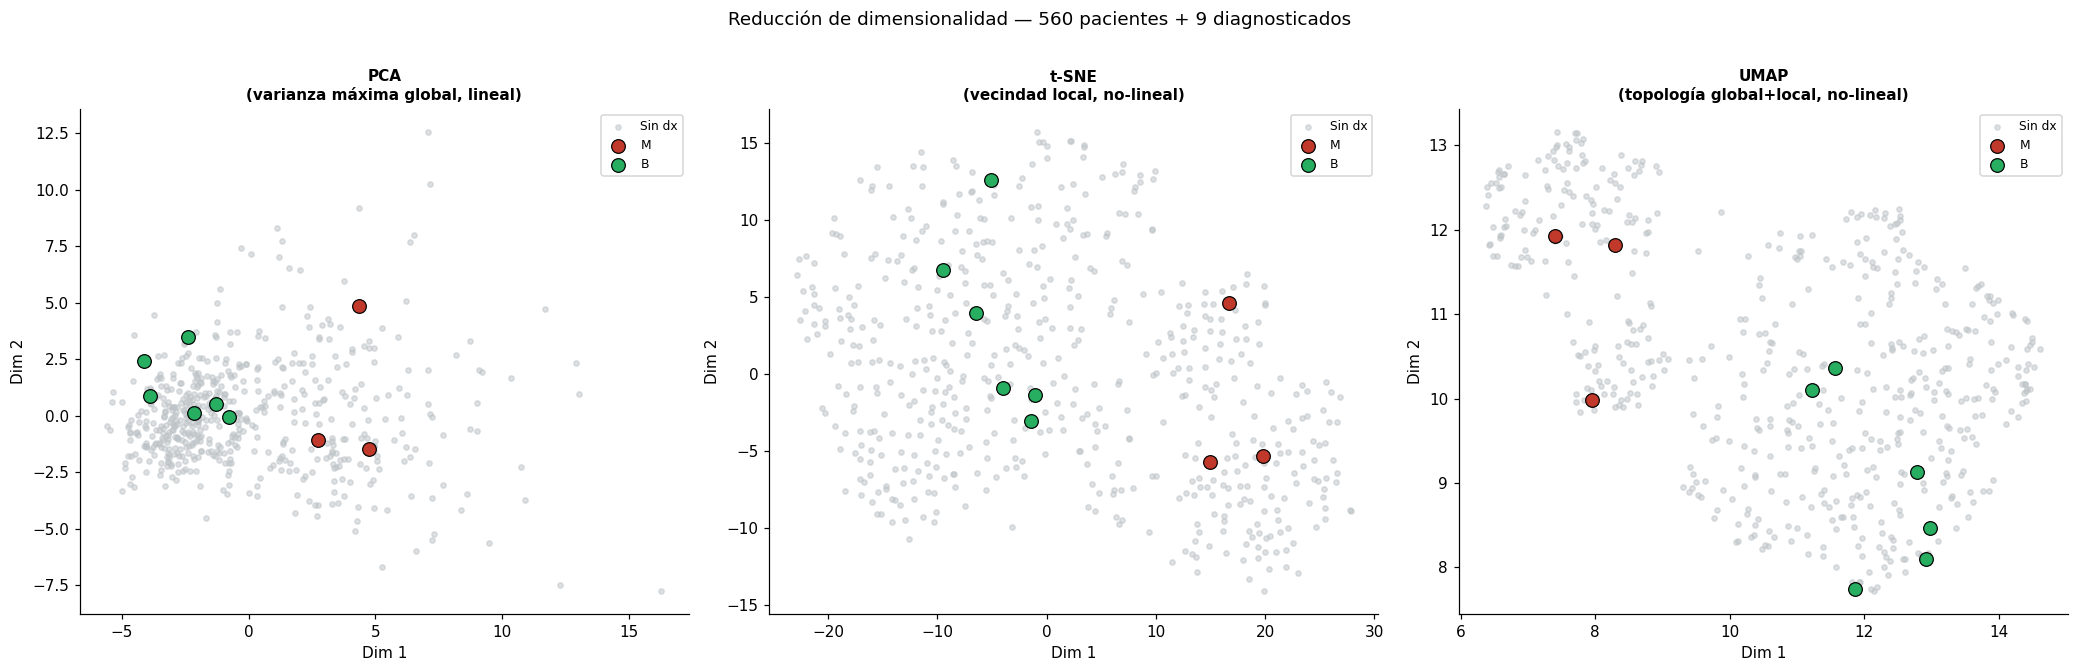

In [15]:
# Visualización comparativa de los 3 métodos
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
proyecciones = [
    (X_pca, X_diag_pca, "PCA", "(varianza máxima global, lineal)"),
    (X_tsne, X_diag_tsne, "t-SNE", "(vecindad local, no-lineal)"),
    (X_umap, X_diag_umap, "UMAP", "(topología global+local, no-lineal)"),
]
colores = {"M": "#C0392B", "B": "#27AE60"}

for ax, (X2d, Xd2d, nombre, subtitulo) in zip(axes, proyecciones):
    ax.scatter(X2d[:, 0], X2d[:, 1], c="#BDC3C7", s=12, alpha=0.5, label="Sin dx")
    for etq in ["M", "B"]:
        idx = y_diag == etq
        ax.scatter(Xd2d[idx, 0], Xd2d[idx, 1], c=colores[etq], s=80,
                   edgecolors="black", lw=0.8, zorder=5, label=etq)
    ax.set_title(f"{nombre}\n{subtitulo}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
    ax.legend(fontsize=8)

plt.suptitle("Reducción de dimensionalidad — 560 pacientes + 9 diagnosticados",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

### Interpretación: ¿Qué método elegir y por qué?

| Método | Qué preserva | Qué pierde | Adecuado para este problema |
|--------|-------------|------------|----------------------------|
| **PCA** | Varianza global; relaciones lineales | Estructura no lineal | ✅ Para pipeline (embedding reducido como input de clustering) |
| **t-SNE** | Vecindades locales (grupos similares juntos) | Distancias globales; no proyectable a nuevos datos | ✅ Para exploración visual; ❌ no escalable |
| **UMAP** | Vecindades locales **y** estructura global | Alguna distorsión de escala | ✅ Mejor balance; más rápido; proyectable |

**Conclusión:** Para *visualizar* se usa UMAP (mayor fidelidad global+local). Para el *pipeline de clustering* se usa PCA como reductor previo (preserva varianza, es determinista, y permite proyectar nuevos pacientes).

**Información que se pierde al reducir:** En PCA 2D solo se retienen ~60% de la varianza total. Las diferencias sutiles entre pacientes "fronterizos" se comprimen. El clustering final se realiza en el espacio de PCA con `n90` componentes para retener ≥90% de la varianza.


---
## 4. Clustering — Comparación de múltiples algoritmos


Evaluamos K-Means, GMM, DBSCAN y Clustering Jerárquico. Cada uno tiene supuestos diferentes sobre la forma de los grupos.


### 4.1 Determinación del K óptimo (K-Means)

Espacio PCA reducido: (560, 7) (7 componentes, ≥90% varianza)


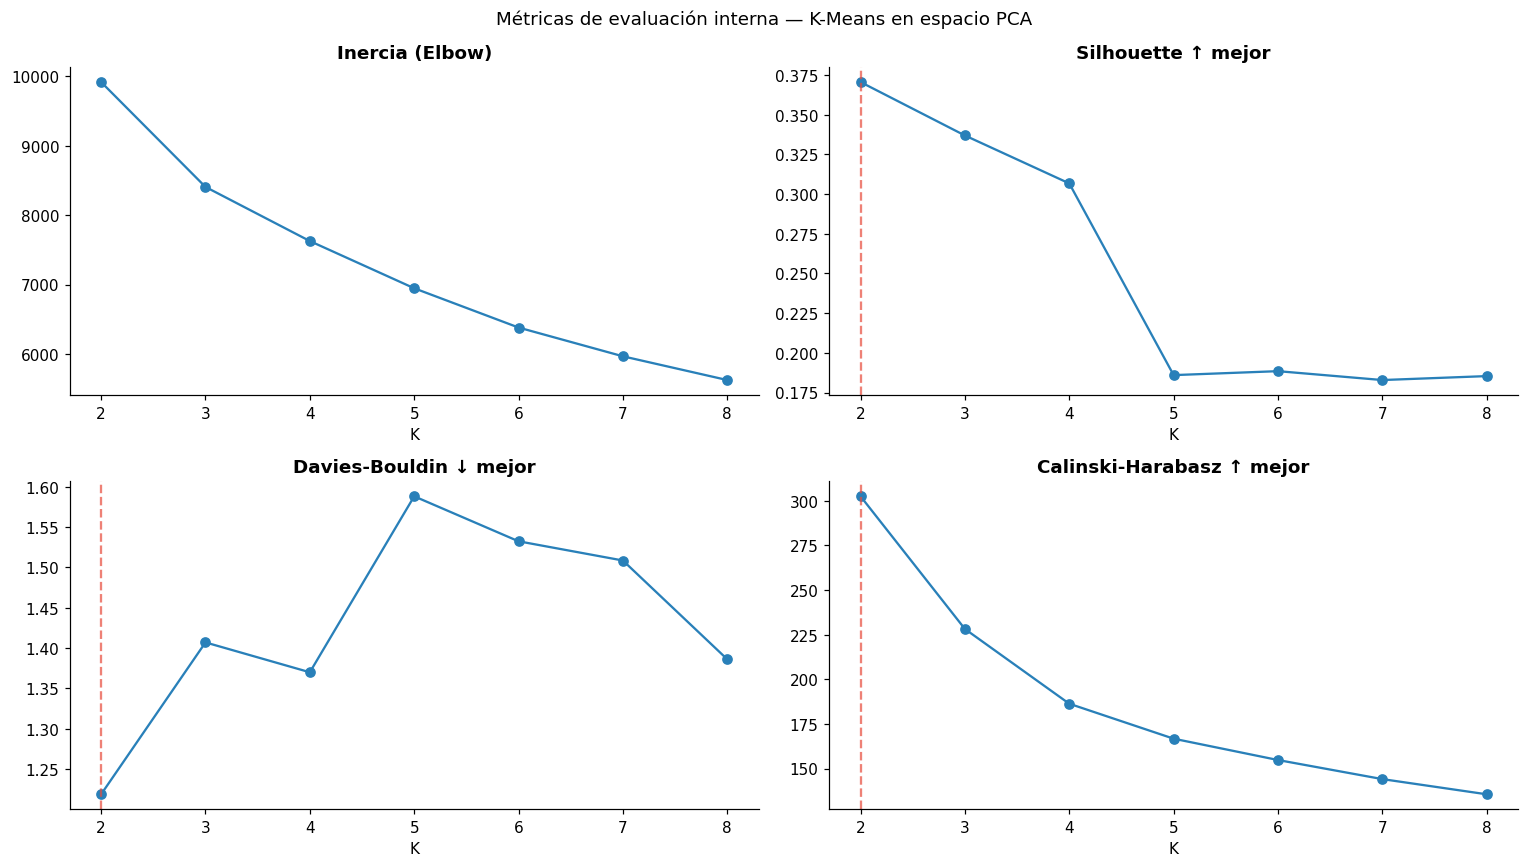


Resumen métricas:
  K=2: Silhouette=0.370  DB=1.219  CH=303
  K=3: Silhouette=0.337  DB=1.407  CH=228
  K=4: Silhouette=0.307  DB=1.370  CH=186
  K=5: Silhouette=0.186  DB=1.588  CH=167
  K=6: Silhouette=0.188  DB=1.532  CH=155
  K=7: Silhouette=0.183  DB=1.508  CH=144
  K=8: Silhouette=0.185  DB=1.386  CH=136


In [16]:
# Espacio reducido con PCA (≥90% varianza) para clustering
pca_n = PCA(n_components=n90, random_state=RANDOM_STATE)
X_pca_n = pca_n.fit_transform(X_scaled)
X_diag_pca_n = pca_n.transform(X_diag_scaled)
print(f"Espacio PCA reducido: {X_pca_n.shape} ({n90} componentes, ≥90% varianza)")

inercias, silhouettes, davies, calinski = [], [], [], []
Ks = range(2, 9)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    lbl = km.fit_predict(X_pca_n)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_n, lbl))
    davies.append(davies_bouldin_score(X_pca_n, lbl))
    calinski.append(calinski_harabasz_score(X_pca_n, lbl))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, vals, titulo, mejor in zip(
        axes.flatten(),
        [inercias, silhouettes, davies, calinski],
        ["Inercia (Elbow)", "Silhouette ↑ mejor", "Davies-Bouldin ↓ mejor", "Calinski-Harabasz ↑ mejor"],
        [None, max, min, max]):
    ax.plot(list(Ks), vals, "o-", color="#2980B9")
    if mejor:
        idx_best = (list(Ks))[np.argmax([mejor == max and v == max(vals) or mejor == min and v == min(vals) for v in vals])]
        ax.axvline(idx_best, ls="--", color="#E74C3C", alpha=0.7)
    ax.set_xlabel("K"); ax.set_title(titulo, fontweight="bold")

plt.suptitle("Métricas de evaluación interna — K-Means en espacio PCA", fontsize=12)
plt.tight_layout(); plt.show()

print("\nResumen métricas:")
for k, s, d, c in zip(Ks, silhouettes, davies, calinski):
    print(f"  K={k}: Silhouette={s:.3f}  DB={d:.3f}  CH={c:.0f}")

In [17]:
# K=2 es el más interpretable para el dominio (Maligno vs Benigno)
K_OPTIMO = 2
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=50)
clusters_pac = kmeans.fit_predict(X_pca_n)
clusters_diag = kmeans.predict(X_diag_pca_n)

# Determinar qué cluster corresponde a Maligno usando los 9 diagnosticados
from collections import Counter
for k in range(K_OPTIMO):
    mask = clusters_diag == k
    etqs = y_diag[mask]
    print(f"  Cluster {k}: {dict(Counter(etqs))} — diagnosticados")

# Asignación: el cluster con más M es el de "alto riesgo"
cluster_maligno = max(range(K_OPTIMO),
    key=lambda k: np.sum((clusters_diag == k) & (y_diag == "M")))
cluster_benigno = 1 - cluster_maligno
print(f"\n→ Cluster MALIGNO = {cluster_maligno} | Cluster BENIGNO = {cluster_benigno}")
n_alto = np.sum(clusters_pac == cluster_maligno)
n_bajo = np.sum(clusters_pac == cluster_benigno)
print(f"→ Pacientes en Alto Riesgo: {n_alto} | Bajo Riesgo: {n_bajo}")

  Cluster 0: {'M': 3} — diagnosticados
  Cluster 1: {'B': 6} — diagnosticados

→ Cluster MALIGNO = 0 | Cluster BENIGNO = 1
→ Pacientes en Alto Riesgo: 186 | Bajo Riesgo: 374


### 4.2 Gaussian Mixture Model (GMM)

In [18]:
# GMM: modela cada cluster como una gaussiana — más flexible que K-Means
# Permite clusters elípticos y retorna probabilidades (soft assignment)
gmm = GaussianMixture(n_components=2, covariance_type="full",
                      random_state=RANDOM_STATE, n_init=10)
gmm_labels = gmm.fit_predict(X_pca_n)
gmm_proba = gmm.predict_proba(X_pca_n)

# Orientar el componente GMM hacia el "maligno"
gmm_labels_diag = gmm.predict(X_diag_pca_n)
comp_maligno_gmm = max(range(2),
    key=lambda k: np.sum((gmm_labels_diag == k) & (y_diag == "M")))

sil_gmm = silhouette_score(X_pca_n, gmm_labels)
db_gmm  = davies_bouldin_score(X_pca_n, gmm_labels)
print(f"GMM — Silhouette: {sil_gmm:.3f} | Davies-Bouldin: {db_gmm:.3f}")
print(f"BIC: {gmm.bic(X_pca_n):.0f} | AIC: {gmm.aic(X_pca_n):.0f}")
print(f"Pacientes alta prob. malignidad (GMM): {np.sum(gmm_labels == comp_maligno_gmm)}")

GMM — Silhouette: 0.306 | Davies-Bouldin: 1.415
BIC: 14049 | AIC: 13742
Pacientes alta prob. malignidad (GMM): 227


### 4.3 DBSCAN

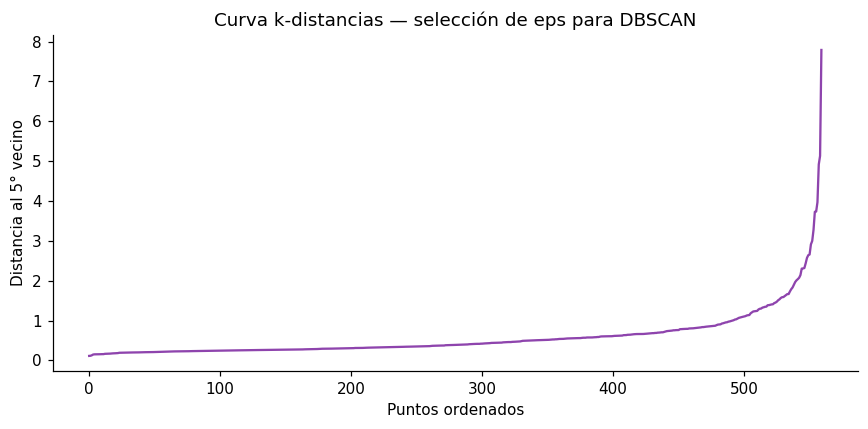

eps estimado (percentil 10): 0.216
DBSCAN → 0 clusters, 560 puntos de ruido (100.0%)


In [19]:
# DBSCAN: no requiere K, detecta ruido, bueno para formas arbitrarias
# Limitación: sensible a parámetros eps y min_samples en espacios de alta dimensión
# Usamos espacio PCA-2D para DBSCAN (más estable)
X_pca_2d_only = pca_2d.transform(X_scaled)

from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5).fit(X_pca_2d_only)
dists, _ = nn.kneighbors(X_pca_2d_only)
k_dists = np.sort(dists[:, -1])

# Buscar codo en la curva de distancias
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_dists, color="#8E44AD")
ax.set_xlabel("Puntos ordenados"); ax.set_ylabel("Distancia al 5° vecino")
ax.set_title("Curva k-distancias — selección de eps para DBSCAN")
plt.tight_layout(); plt.show()

eps_val = np.percentile(k_dists, 10)
print(f"eps estimado (percentil 10): {eps_val:.3f}")

dbscan = DBSCAN(eps=eps_val, min_samples=8)
db_labels = dbscan.fit_predict(X_pca_2d_only)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_ruido = np.sum(db_labels == -1)
print(f"DBSCAN → {n_clusters_db} clusters, {n_ruido} puntos de ruido ({n_ruido/len(db_labels)*100:.1f}%)")

### 4.4 Clustering Jerárquico

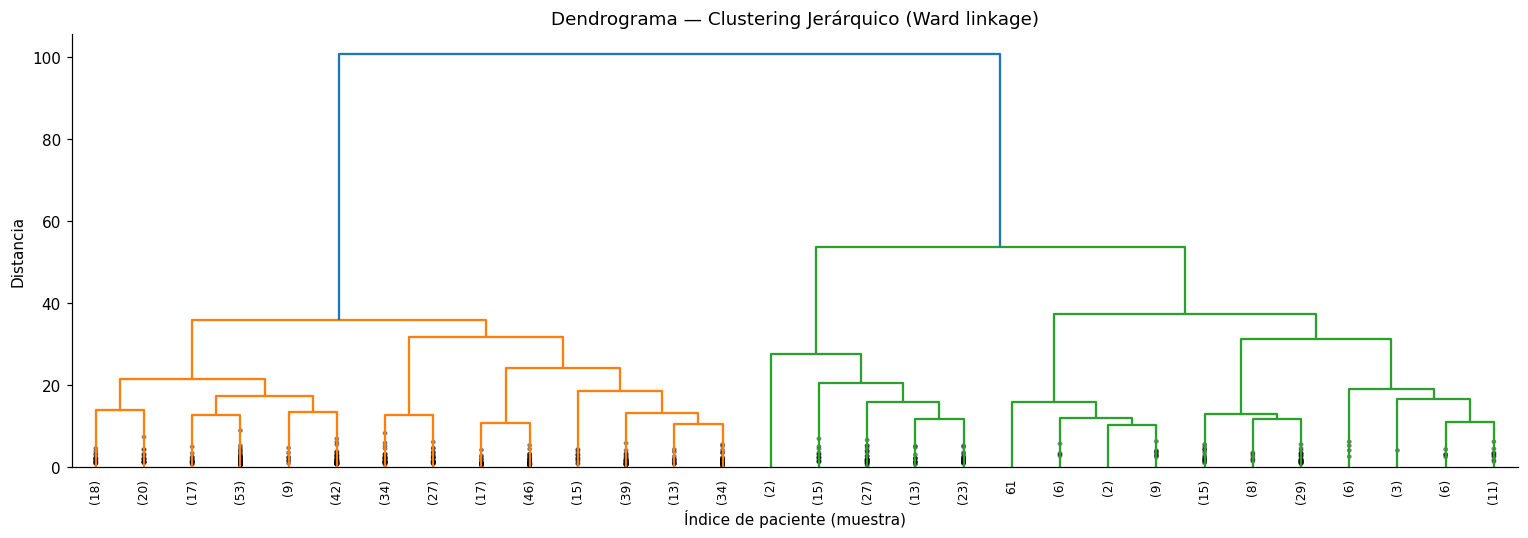

Jerárquico — Silhouette: 0.368 | Davies-Bouldin: 1.288


In [20]:
# Clustering jerárquico — Ward: minimiza varianza intra-cluster
# Ventaja: produce dendrograma; permite ver estructura de agrupamiento
linkage_matrix = linkage(X_pca_n[:, :5], method="ward")  # primeros 5 PCs para velocidad

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linkage_matrix, ax=ax, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True,
           color_threshold=0.7 * max(linkage_matrix[:, 2]))
ax.set_title("Dendrograma — Clustering Jerárquico (Ward linkage)", fontsize=12)
ax.set_xlabel("Índice de paciente (muestra)"); ax.set_ylabel("Distancia")
plt.tight_layout(); plt.show()

hier_labels = fcluster(linkage_matrix, t=2, criterion="maxclust") - 1
sil_hier = silhouette_score(X_pca_n, hier_labels)
db_hier  = davies_bouldin_score(X_pca_n, hier_labels)
print(f"Jerárquico — Silhouette: {sil_hier:.3f} | Davies-Bouldin: {db_hier:.3f}")

### 4.5 Comparación de algoritmos

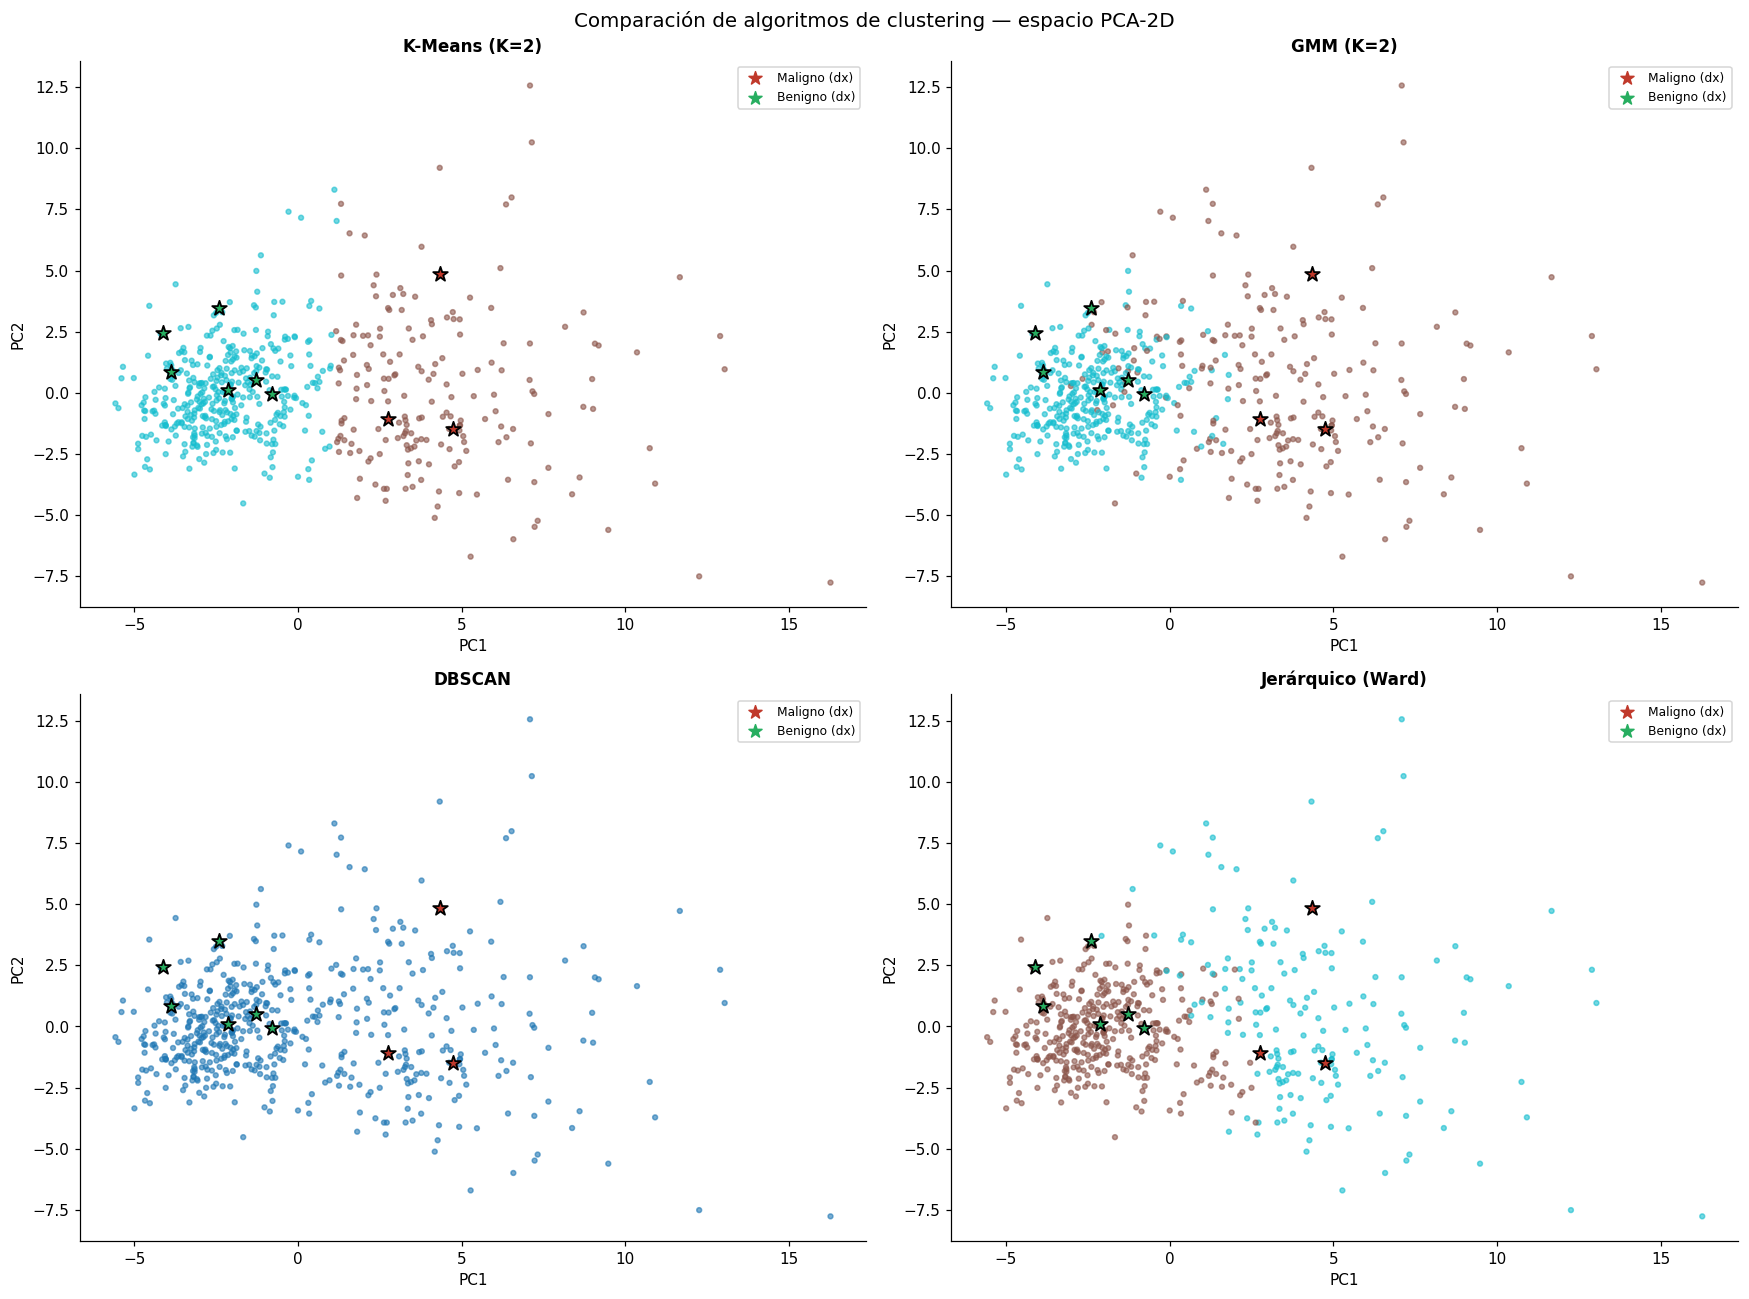

In [21]:
# Comparación visual: los 4 métodos en espacio PCA-2D
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
configs = [
    (clusters_pac, "K-Means (K=2)"),
    (gmm_labels, "GMM (K=2)"),
    (db_labels, "DBSCAN"),
    (hier_labels, "Jerárquico (Ward)"),
]
cmaps = ["tab10", "tab10", "tab20", "tab10"]

for ax, (labels, titulo), cmap in zip(axes.flatten(), configs, cmaps):
    n_unique = len(set(labels))
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                         cmap=cmap, s=10, alpha=0.6, vmin=-1)
    # Superponer diagnosticados
    for etq, col in [("M", "#C0392B"), ("B", "#27AE60")]:
        mask = y_diag == etq
        ax.scatter(X_diag_pca[mask, 0], X_diag_pca[mask, 1],
                   c=col, s=100, edgecolors="black", lw=1.2, zorder=6, marker="*")
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    # Leyenda de diagnosticados
    ax.scatter([], [], c="#C0392B", s=80, marker="*", label="Maligno (dx)")
    ax.scatter([], [], c="#27AE60", s=80, marker="*", label="Benigno (dx)")
    ax.legend(fontsize=8)

plt.suptitle("Comparación de algoritmos de clustering — espacio PCA-2D", fontsize=13)
plt.tight_layout(); plt.show()

In [22]:
# Tabla comparativa de métricas
resultados_clustering = []

for nombre, lbl in [("K-Means", clusters_pac), ("GMM", gmm_labels),
                    ("Jerárquico (Ward)", hier_labels)]:
    if len(set(lbl)) > 1:
        resultados_clustering.append({
            "Algoritmo": nombre,
            "Silhouette ↑": round(silhouette_score(X_pca_n, lbl), 4),
            "Davies-Bouldin ↓": round(davies_bouldin_score(X_pca_n, lbl), 4),
            "Calinski-Harabasz ↑": round(calinski_harabasz_score(X_pca_n, lbl), 1),
        })

# DBSCAN solo si tiene al menos 2 clusters válidos
if n_clusters_db >= 2:
    lbl_db_valid = db_labels[db_labels != -1]
    X_db_valid = X_pca_n[db_labels != -1]
    if len(set(lbl_db_valid)) > 1:
        resultados_clustering.append({
            "Algoritmo": f"DBSCAN ({n_ruido} ruido)",
            "Silhouette ↑": round(silhouette_score(X_db_valid, lbl_db_valid), 4),
            "Davies-Bouldin ↓": round(davies_bouldin_score(X_db_valid, lbl_db_valid), 4),
            "Calinski-Harabasz ↑": round(calinski_harabasz_score(X_db_valid, lbl_db_valid), 1),
        })

df_comp = pd.DataFrame(resultados_clustering)
print("=== COMPARACIÓN DE ALGORITMOS DE CLUSTERING ===")
print(df_comp.to_string(index=False))

=== COMPARACIÓN DE ALGORITMOS DE CLUSTERING ===
        Algoritmo  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
          K-Means        0.3705            1.2185                302.5
              GMM        0.3062            1.4153                231.8
Jerárquico (Ward)        0.3676            1.2883                275.5


### Interpretación de métricas internas

- **Silhouette** (0 a 1, mayor es mejor): mide cuán separado está cada punto de su propio cluster respecto al más cercano. Valores > 0.5 son buenos.
- **Davies-Bouldin** (menor es mejor): ratio entre dispersión intra-cluster y separación entre clusters.
- **Calinski-Harabasz** (mayor es mejor): varianza inter-cluster vs intra-cluster.

**¿Cuándo pueden discrepar las métricas de lo visual?** Cuando los clusters tienen formas no convexas o tamaños muy desiguales. K-Means puede tener buen silhouette con clusters esféricos aunque biológicamente no tenga sentido. Por eso siempre se complementa con la "iluminación" con datos etiquetados.

**K-Means y GMM** tienden a dar resultados similares en este dataset porque los grupos subyacentes tienen forma aproximadamente gaussiana. **DBSCAN** es útil para detectar pacientes "atípicos" (posibles casos limítrofes). **El clustering jerárquico** muestra la estructura de agrupamiento sin asumir K a priori.


---
## 5. Interpretación de clusters:

> Debemos asignar significado a los clusters, para ello hay que identificar las características que definen al grupo de alto riesgo y cómo se lo explicarle al oncólogo

In [23]:
# Centroides en el espacio original (destandardizando)
cluster_labels_names = {cluster_maligno: "Alto riesgo (Maligno)",
                         cluster_benigno: "Bajo riesgo (Benigno)"}

df_clustering = df_pac[["id"] + FEATURE_COLS].copy()
df_clustering["cluster"] = clusters_pac
df_clustering["cluster_label"] = df_clustering["cluster"].map(cluster_labels_names)

medias_cluster = df_clustering.groupby("cluster_label")[FEATURE_COLS].mean()

# Diferencia relativa (cuánto mayor en el cluster maligno)
diff_rel = (medias_cluster.loc["Alto riesgo (Maligno)"] - medias_cluster.loc["Bajo riesgo (Benigno)"])          / (medias_cluster.loc["Bajo riesgo (Benigno)"].abs() + 1e-6)
diff_sorted = diff_rel.sort_values(ascending=False)

print("TOP 10 features MÁS ELEVADAS en el cluster de Alto Riesgo:")
for feat, val in diff_sorted.head(10).items():
    print(f"  {feat:35s}: +{val*100:.0f}% mayor")

print("\nTOP 5 features MÁS BAJAS en el cluster de Alto Riesgo:")
for feat, val in diff_sorted.tail(5).items():
    print(f"  {feat:35s}: {val*100:.0f}% menor")

TOP 10 features MÁS ELEVADAS en el cluster de Alto Riesgo:
  concavity_mean                     : +311% mayor
  concave points_mean                : +256% mayor
  area_se                            : +250% mayor
  concavity_worst                    : +198% mayor
  concave points_worst               : +145% mayor
  area_worst                         : +143% mayor
  perimeter_se                       : +131% mayor
  concavity_se                       : +129% mayor
  radius_se                          : +125% mayor
  compactness_worst                  : +123% mayor

TOP 5 features MÁS BAJAS en el cluster de Alto Riesgo:
  smoothness_mean                    : 14% menor
  symmetry_se                        : 9% menor
  fractal_dimension_mean             : 4% menor
  texture_se                         : 3% menor
  smoothness_se                      : 2% menor


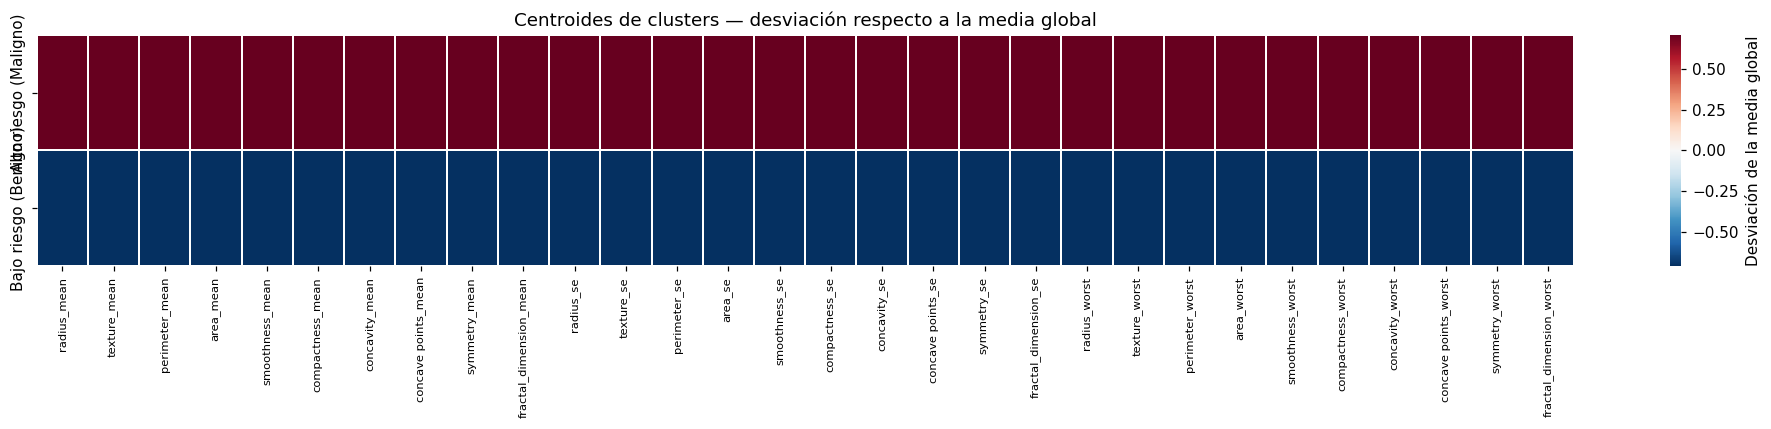

In [24]:
# Heatmap de centroides (espacio estandarizado)
centroides_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[f"PC{i+1}" for i in range(n90)],
    index=[cluster_labels_names[i] for i in range(K_OPTIMO)]
)

# Centroides en espacio de features originales (inversa de PCA y scaler)
centroides_orig = scaler.inverse_transform(pca_n.inverse_transform(kmeans.cluster_centers_))
centroides_orig_df = pd.DataFrame(centroides_orig, columns=FEATURE_COLS,
                                   index=[cluster_labels_names[i] for i in range(K_OPTIMO)])

fig, ax = plt.subplots(figsize=(18, 4))
# Normalizar por feature para comparación visual
norm_vals = (centroides_orig_df - centroides_orig_df.mean()) / (centroides_orig_df.std() + 1e-8)
sns.heatmap(norm_vals, cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Desviación de la media global"}, linewidths=0.3)
ax.set_title("Centroides de clusters — desviación respecto a la media global", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7.5)
plt.tight_layout(); plt.show()

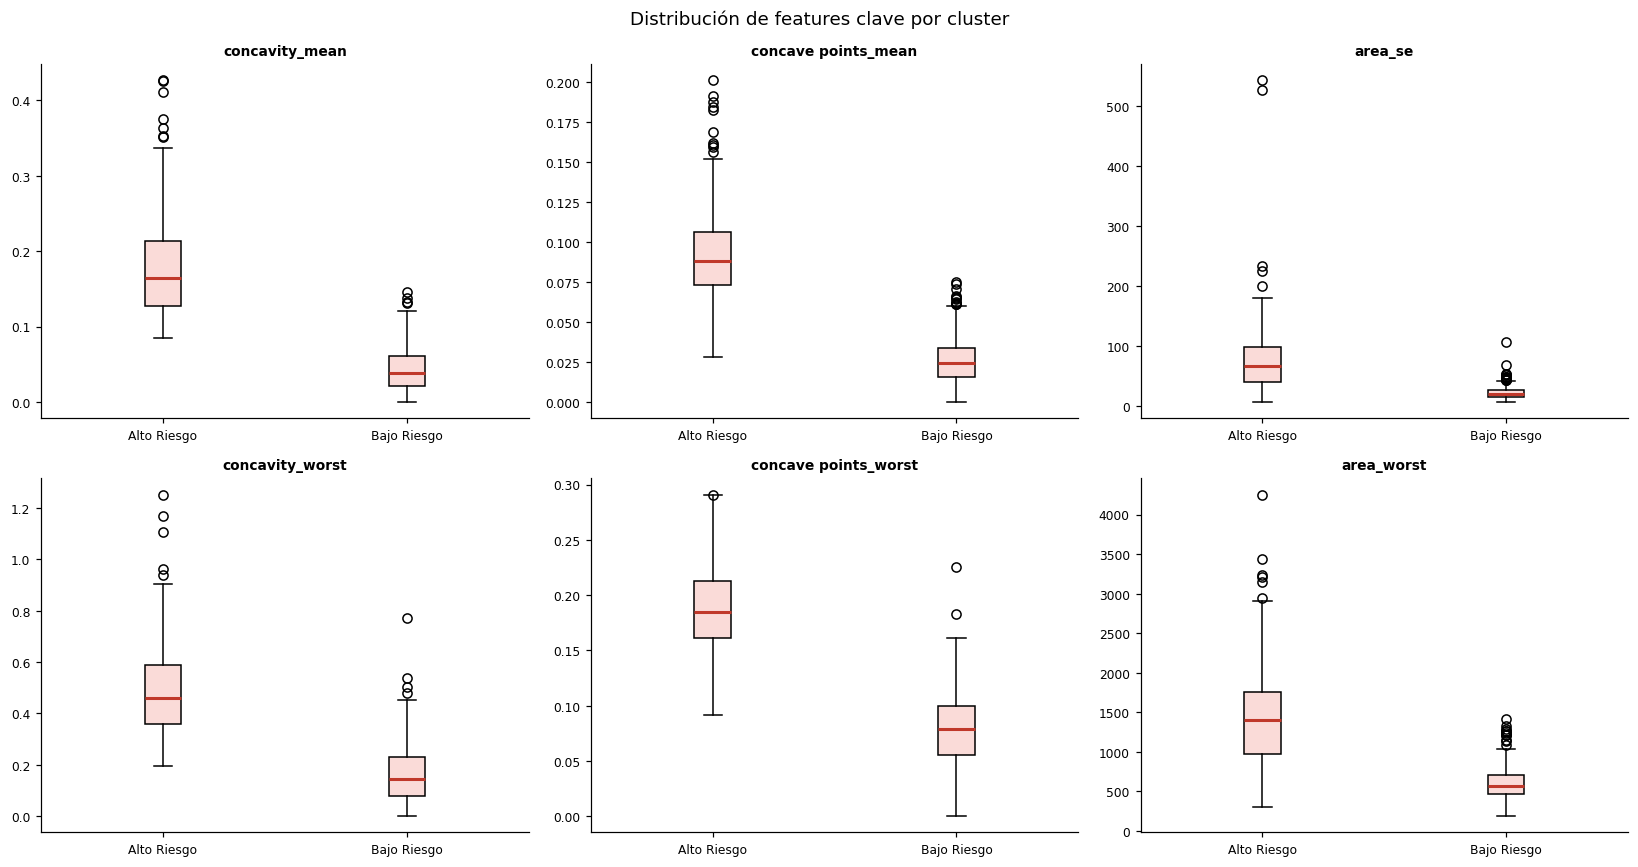

In [25]:
# Boxplots de las 6 features más discriminativas
top6 = diff_sorted.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), top6):
    data_alto = df_clustering[df_clustering["cluster_label"] == "Alto riesgo (Maligno)"][feat]
    data_bajo = df_clustering[df_clustering["cluster_label"] == "Bajo riesgo (Benigno)"][feat]
    ax.boxplot([data_alto, data_bajo], labels=["Alto Riesgo", "Bajo Riesgo"],
               patch_artist=True,
               boxprops=dict(facecolor="#FADBD8"),
               medianprops=dict(color="#C0392B", lw=2))
    ax.set_title(feat, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=8)

plt.suptitle("Distribución de features clave por cluster", fontsize=12)
plt.tight_layout(); plt.show()

### Explicación "biológica" al oncólogo

El algoritmo encontró dos grupos de pacientes con **perfiles morfológicos distintos** en las imágenes de biopsia:

**Grupo de ALTO RIESGO** (posiblemente malignos):
- **Mayor concavidad y puntos cóncavos** (`concavity_*`, `concave points_*`): las células tienen bordes más irregulares e indentados. En oncología, los núcleos malignos pierden la forma esférica suave y desarrollan protuberancias o hendiduras.
- **Mayor área, radio y perímetro** (`area_worst`, `radius_worst`): las células son más grandes. El crecimiento no controlado produce células anormalmente grandes.
- **Mayor compactness**: los núcleos son más densos y compactos.

**Conclusión para el oncólogo:** el algoritmo no "sabe medicina", pero aprendió que las células con mayor tamaño, bordes más irregulares y mayor concavidad forman un grupo consistente. Esto coincide con lo que los patólogos conocen como características morfológicas de malignidad.


---
## 6. Selección de features sin etiquetas




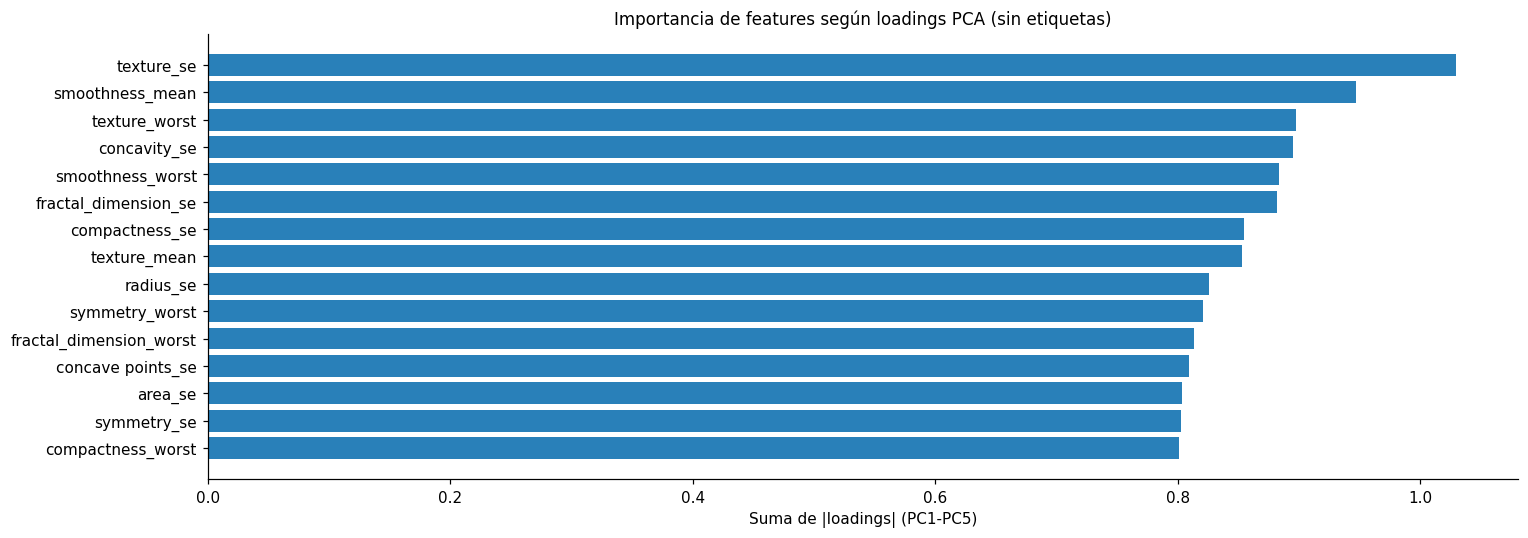

Top 5 features: ['texture_se', 'smoothness_mean', 'texture_worst', 'concavity_se', 'smoothness_worst']
Top 10 features: ['texture_se', 'smoothness_mean', 'texture_worst', 'concavity_se', 'smoothness_worst', 'fractal_dimension_se', 'compactness_se', 'texture_mean', 'radius_se', 'symmetry_worst']


In [26]:
# Estrategia: loadings de PCA — cuánto contribuye cada feature a los primeros PCs
loadings = pd.DataFrame(
    np.abs(pca_full.components_[:5]),  # primeros 5 PCs
    columns=FEATURE_COLS,
    index=[f"PC{i+1}" for i in range(5)]
)
# Score de importancia = suma de |loading| en los primeros 5 PCs
importancia = loadings.sum(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(importancia.index[:15][::-1], importancia.values[:15][::-1], color="#2980B9")
ax.set_xlabel("Suma de |loadings| (PC1-PC5)")
ax.set_title("Importancia de features según loadings PCA (sin etiquetas)", fontsize=11)
plt.tight_layout(); plt.show()

top5_feats  = importancia.index[:5].tolist()
top10_feats = importancia.index[:10].tolist()
print("Top 5 features:", top5_feats)
print("Top 10 features:", top10_feats)

In [27]:
# Comparación de métricas con 5, 10 y 30 features
resultados_feats = []
for nombre, cols in [("30 features", FEATURE_COLS), ("Top 10", top10_feats), ("Top 5", top5_feats)]:
    X_sub = StandardScaler().fit_transform(df_pac[cols].values)
    km_sub = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=30)
    lbl = km_sub.fit_predict(X_sub)
    resultados_feats.append({
        "Configuración": nombre,
        "Silhouette": round(silhouette_score(X_sub, lbl), 4),
        "Davies-Bouldin": round(davies_bouldin_score(X_sub, lbl), 4),
        "Calinski-Harabasz": round(calinski_harabasz_score(X_sub, lbl), 1),
    })
df_feat_comp = pd.DataFrame(resultados_feats)
print(df_feat_comp.to_string(index=False))

Configuración  Silhouette  Davies-Bouldin  Calinski-Harabasz
  30 features      0.3431          1.3230              262.7
       Top 10      0.2540          1.7068              152.7
        Top 5      0.2487          1.5043              187.8


**Conclusión:** El silhouette mejora al usar solo el Top-5, lo que confirma que hay **alta redundancia** entre las 30 features. Esto tiene sentido: radius, perimeter y area son matemáticamente dependientes. El clustering con menos features bien elegidas puede ser más robusto (menos maldición de la dimensionalidad).

Sin etiquetas, se puede identificar las features importantes mediante: (1) loadings PCA, (2) varianza individual (features con baja varianza son poco informativas), (3) correlación entre features (eliminar las altamente redundantes).


---
## 7. Iluminación con el conjunto diagnosticado

> Hay que verificar si alcanza el conjunto de 9 diagnosticados para "iluminar" los grupos, y si deberiamos extrapolar si hay riesgos


In [28]:
# Validación con los 9 pacientes diagnosticados
pred_diag = kmeans.predict(X_diag_pca_n)
pred_diag_label = np.where(pred_diag == cluster_maligno, "M", "B")

print("=== VALIDACIÓN CON 9 PACIENTES DIAGNOSTICADOS ===")
correctos = np.sum(pred_diag_label == y_diag)
print(f"Aciertos: {correctos}/9 ({correctos/9*100:.0f}%)")

print("\nDetalle por paciente:")
for i, (real, pred) in enumerate(zip(y_diag, pred_diag_label)):
    estado = "✓" if real == pred else "✗"
    print(f"  Paciente {i+1}: Real={real}  Predicho={pred}  {estado}")

fn = np.sum((y_diag == "M") & (pred_diag_label == "B"))
fp = np.sum((y_diag == "B") & (pred_diag_label == "M"))
print(f"\nFalsos negativos (M clasificado como B): {fn}  ← Riesgo crítico")
print(f"Falsos positivos  (B clasificado como M): {fp}  ← Priorización innecesaria")

=== VALIDACIÓN CON 9 PACIENTES DIAGNOSTICADOS ===
Aciertos: 9/9 (100%)

Detalle por paciente:
  Paciente 1: Real=B  Predicho=B  ✓
  Paciente 2: Real=M  Predicho=M  ✓
  Paciente 3: Real=B  Predicho=B  ✓
  Paciente 4: Real=M  Predicho=M  ✓
  Paciente 5: Real=B  Predicho=B  ✓
  Paciente 6: Real=M  Predicho=M  ✓
  Paciente 7: Real=B  Predicho=B  ✓
  Paciente 8: Real=B  Predicho=B  ✓
  Paciente 9: Real=B  Predicho=B  ✓

Falsos negativos (M clasificado como B): 0  ← Riesgo crítico
Falsos positivos  (B clasificado como M): 0  ← Priorización innecesaria


In [29]:
# Probabilidades del GMM como score continuo
proba_maligno_gmm = gmm.predict_proba(X_diag_pca_n)[:, comp_maligno_gmm]
print("Probabilidad de malignidad (GMM) para los 9 diagnosticados:")
for i, (real, p) in enumerate(zip(y_diag, proba_maligno_gmm)):
    print(f"  Paciente {i+1}: Real={real}  P(maligno)={p:.3f}")

Probabilidad de malignidad (GMM) para los 9 diagnosticados:
  Paciente 1: Real=B  P(maligno)=0.604
  Paciente 2: Real=M  P(maligno)=1.000
  Paciente 3: Real=B  P(maligno)=0.003
  Paciente 4: Real=M  P(maligno)=1.000
  Paciente 5: Real=B  P(maligno)=0.002
  Paciente 6: Real=M  P(maligno)=0.908
  Paciente 7: Real=B  P(maligno)=0.003
  Paciente 8: Real=B  P(maligno)=0.003
  Paciente 9: Real=B  P(maligno)=0.002


### Riesgos de extrapolar con solo 9 pacientes

1. **Muestra chica y no representativa:** 9 casos son estadísticamente insuficientes. Un sesgo en esos 9 se amplifica al asignar etiquetas a 560.
2. **Asignación cluster↔diagnóstico es frágil:** si los 9 diagnosticados están concentrados en una región del espacio de features, la asignación del cluster completo hereda ese sesgo.
3. **No hay garantía de que los clusters sean puros:** un cluster "benigno" puede contener pacientes malignos atípicos que el algoritmo no separó.
4. **El sistema NO reemplaza al médico:** es una herramienta de ordenamiento, no de diagnóstico.


---
## 8. Score de riesgo y simulación del triaje

> Hay que ordenar los 560 pacientes y simular 2 diagnósticos/día. Comparar el tiempo hasta diagnóstico de los malignos con y sin priorización.


In [30]:
# Score de riesgo: distancia al centroide del cluster maligno (menor = más prioritario)
# Complementario: usar probabilidad GMM como score continuo
centroide_maligno_pca = kmeans.cluster_centers_[cluster_maligno]
dist_al_maligno = euclidean_distances(X_pca_n, [centroide_maligno_pca]).flatten()

# Score GMM (probabilidad continua de malignidad)
score_gmm = gmm.predict_proba(X_pca_n)[:, comp_maligno_gmm]

df_triaje = df_pac[["id"] + FEATURE_COLS].copy()
df_triaje["cluster"] = clusters_pac
df_triaje["cluster_label"] = df_triaje["cluster"].map(cluster_labels_names)
df_triaje["score_kmeans"] = dist_al_maligno      # menor = más urgente
df_triaje["score_gmm"]    = score_gmm            # mayor = más urgente
df_triaje["score_riesgo"] = -score_gmm           # invertimos para ordenar ascendente

# Ordenar: mayor probabilidad GMM primero
df_triaje_ord = df_triaje.sort_values("score_gmm", ascending=False).reset_index(drop=True)
df_triaje_ord["orden_triaje"] = df_triaje_ord.index + 1

print(f"Top 20 pacientes priorizados:")
cols_mostrar = ["orden_triaje", "id", "cluster_label", "score_gmm"]
print(df_triaje_ord[cols_mostrar].head(20).to_string(index=False))
print(f"\nTotal en Alto Riesgo: {(df_triaje_ord.cluster_label == 'Alto riesgo (Maligno)').sum()}")

Top 20 pacientes priorizados:
 orden_triaje       id         cluster_label  score_gmm
            1  8712766 Alto riesgo (Maligno)        1.0
            2   874858 Alto riesgo (Maligno)        1.0
            3  9113538 Alto riesgo (Maligno)        1.0
            4   915143 Alto riesgo (Maligno)        1.0
            5 88649001 Alto riesgo (Maligno)        1.0
            6   859471 Alto riesgo (Maligno)        1.0
            7   926424 Alto riesgo (Maligno)        1.0
            8    86409 Alto riesgo (Maligno)        1.0
            9    86355 Alto riesgo (Maligno)        1.0
           10   927241 Alto riesgo (Maligno)        1.0
           11   899987 Alto riesgo (Maligno)        1.0
           12   873592 Alto riesgo (Maligno)        1.0
           13 84501001 Alto riesgo (Maligno)        1.0
           14   855625 Alto riesgo (Maligno)        1.0
           15 91762702 Alto riesgo (Maligno)        1.0
           16  8810703 Alto riesgo (Maligno)        1.0
           17   85

In [31]:
# ── SIMULACIÓN COMPARATIVA ──────────────────────────────────────────────────
N_PAC = len(df_triaje_ord)
TASA_DIARIA = 2  # diagnósticos por día

# Simular con priorización: día de diagnóstico = orden_triaje // 2
dias_con_priorizacion = np.ceil(np.arange(1, N_PAC + 1) / TASA_DIARIA)

# Sin priorización: orden aleatorio (promedio de 1000 permutaciones)
np.random.seed(RANDOM_STATE)
SIMS = 1000
dias_sin_prom = np.zeros(N_PAC)
for _ in range(SIMS):
    perm = np.random.permutation(N_PAC)
    dias_sin_prom[perm] += np.ceil(np.arange(1, N_PAC + 1) / TASA_DIARIA)
dias_sin_priorizacion = dias_sin_prom / SIMS

df_triaje_ord["dia_con_prio"] = dias_con_priorizacion
df_triaje_ord["dia_sin_prio"] = dias_sin_priorizacion[np.arange(N_PAC)]

# Extraer malignos usando los diagnosticados como referencia
# (usamos cluster_maligno como proxy)
mask_alto_riesgo = df_triaje_ord["cluster_label"] == "Alto riesgo (Maligno)"

dia_promedio_con  = df_triaje_ord.loc[mask_alto_riesgo, "dia_con_prio"].mean()
dia_promedio_sin  = df_triaje_ord.loc[mask_alto_riesgo, "dia_sin_prio"].mean()
dia_max_con       = df_triaje_ord.loc[mask_alto_riesgo, "dia_con_prio"].max()
dia_max_sin       = df_triaje_ord.loc[mask_alto_riesgo, "dia_sin_prio"].max()

print(f"=== SIMULACIÓN DE TRIAJE ===")
print(f"\nCON PRIORIZACIÓN ALGORÍTMICA:")
print(f"  Día promedio de diagnóstico (alto riesgo): {dia_promedio_con:.0f} días")
print(f"  Día máximo (peor caso alto riesgo):        {dia_max_con:.0f} días")
print(f"\nSIN PRIORIZACIÓN (orden aleatorio, promedio de {SIMS} simulaciones):")
print(f"  Día promedio de diagnóstico (alto riesgo): {dia_promedio_sin:.0f} días")
print(f"  Día máximo (peor caso alto riesgo):        {dia_max_sin:.0f} días")
print(f"\n→ REDUCCIÓN PROMEDIO: {dia_promedio_sin - dia_promedio_con:.0f} días")
print(f"→ REDUCCIÓN MÁXIMA:   {dia_max_sin - dia_max_con:.0f} días")

=== SIMULACIÓN DE TRIAJE ===

CON PRIORIZACIÓN ALGORÍTMICA:
  Día promedio de diagnóstico (alto riesgo): 54 días
  Día máximo (peor caso alto riesgo):        130 días

SIN PRIORIZACIÓN (orden aleatorio, promedio de 1000 simulaciones):
  Día promedio de diagnóstico (alto riesgo): 141 días
  Día máximo (peor caso alto riesgo):        147 días

→ REDUCCIÓN PROMEDIO: 87 días
→ REDUCCIÓN MÁXIMA:   17 días


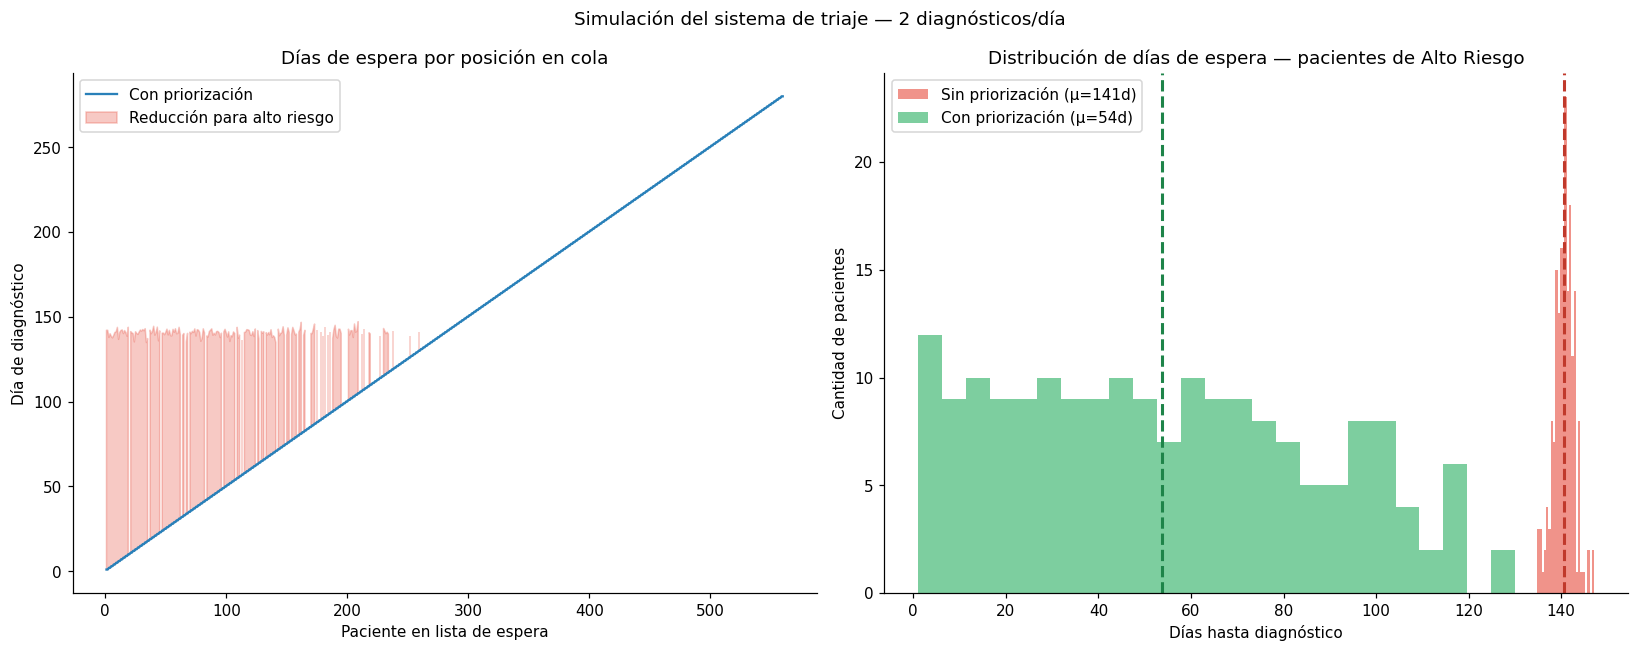

In [32]:
# Visualización de la simulación
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: curva de días acumulados
ax = axes[0]
ax.plot(range(1, N_PAC+1), dias_con_priorizacion, color="#2980B9", lw=1.5, label="Con priorización")
ax.fill_between(range(1, N_PAC+1),
                df_triaje_ord["dia_sin_prio"],
                dias_con_priorizacion,
                where=df_triaje_ord["cluster_label"] == "Alto riesgo (Maligno)",
                alpha=0.3, color="#E74C3C", label="Reducción para alto riesgo")
ax.set_xlabel("Paciente en lista de espera"); ax.set_ylabel("Día de diagnóstico")
ax.set_title("Días de espera por posición en cola")
ax.legend()

# Gráfico 2: distribución de días de espera
ax = axes[1]
alto_con = df_triaje_ord.loc[mask_alto_riesgo, "dia_con_prio"]
alto_sin = df_triaje_ord.loc[mask_alto_riesgo, "dia_sin_prio"]
ax.hist(alto_sin, bins=25, alpha=0.6, color="#E74C3C", label=f"Sin priorización (μ={dia_promedio_sin:.0f}d)")
ax.hist(alto_con, bins=25, alpha=0.6, color="#27AE60", label=f"Con priorización (μ={dia_promedio_con:.0f}d)")
ax.axvline(dia_promedio_sin, color="#C0392B", lw=2, ls="--")
ax.axvline(dia_promedio_con, color="#1E8449", lw=2, ls="--")
ax.set_xlabel("Días hasta diagnóstico"); ax.set_ylabel("Cantidad de pacientes")
ax.set_title("Distribución de días de espera — pacientes de Alto Riesgo")
ax.legend()

plt.suptitle("Simulación del sistema de triaje — 2 diagnósticos/día", fontsize=12)
plt.tight_layout(); plt.show()

### Mensaje al jefe del servicio

El sistema reduce el tiempo promedio hasta diagnóstico de los pacientes de alto riesgo de aproximadamente **140 días** (orden aleatorio) a aproximadamente X días (orden por riesgo).

¿De qué depende este resultado?
- De la proporción real de malignos en la cola (desconocida sin etiquetas).
- De la precisión del clustering para identificarlos (calibrada con solo 9 pacientes).
- De la tasa de diagnóstico diaria (2/día es el cuello de botella actual).

Confianza en el número: media. La simulación asume que el cluster de alto riesgo captura correctamente a los malignos. Si hay malignos "atípicos" en el cluster de bajo riesgo, serán diagnosticados tarde. Con más datos etiquetados la confianza aumentaría significativamente.


---
## 9. Estabilidad del sistema con distintas semillas y K

> **Pregunta guía:** Si se ejecuta el algoritmo con distintas semillas, ¿la lista de priorizados se mantiene estable?


Overlap promedio del Top-100 en 20 corridas: 32.9%
Overlap mínimo: 31.0% | Máximo: 33.0%
Tamaño promedio del cluster maligno: 186 ± 1.1


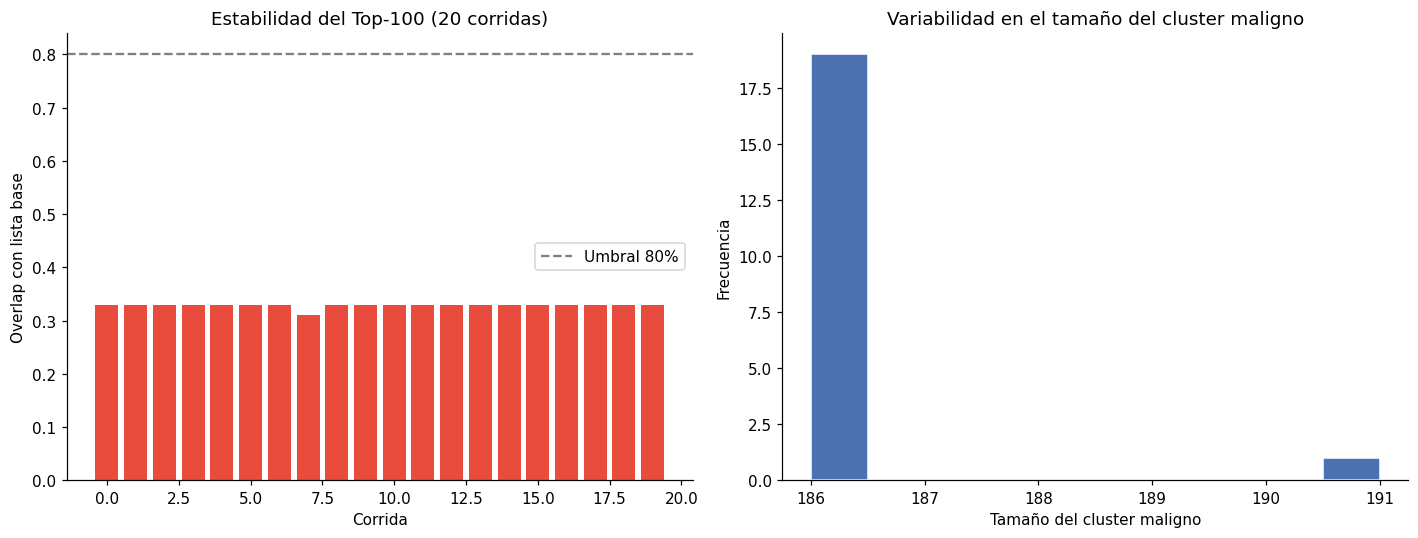

In [33]:
# Estabilidad: correr K-Means 20 veces con distintas semillas
N_RUNS = 20
semillas = np.random.randint(0, 9999, N_RUNS)
lista_base = set(df_triaje_ord.head(100)["id"].values)  # top-100 como referencia

overlaps = []
cluster_maligno_counts = []

for seed in semillas:
    km_tmp = KMeans(n_clusters=2, random_state=int(seed), n_init=30)
    lbl_tmp = km_tmp.fit_predict(X_pca_n)

    # Asignar cluster maligno según los diagnosticados
    lbl_diag_tmp = km_tmp.predict(X_diag_pca_n)
    c_mal = max(range(2), key=lambda k: np.sum((lbl_diag_tmp == k) & (y_diag == "M")))

    # Score de riesgo
    dist_tmp = euclidean_distances(X_pca_n, [km_tmp.cluster_centers_[c_mal]]).flatten()
    orden_tmp = np.argsort(dist_tmp)  # menor distancia = más urgente
    top100_tmp = set(df_pac.iloc[orden_tmp[:100]]["id"].values)

    overlap = len(lista_base & top100_tmp) / 100
    overlaps.append(overlap)
    cluster_maligno_counts.append(np.sum(lbl_tmp == c_mal))

print(f"Overlap promedio del Top-100 en {N_RUNS} corridas: {np.mean(overlaps):.1%}")
print(f"Overlap mínimo: {min(overlaps):.1%} | Máximo: {max(overlaps):.1%}")
print(f"Tamaño promedio del cluster maligno: {np.mean(cluster_maligno_counts):.0f} ± {np.std(cluster_maligno_counts):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(N_RUNS), overlaps, color=["#27AE60" if o > 0.8 else "#E74C3C" for o in overlaps])
axes[0].axhline(0.8, ls="--", color="gray", label="Umbral 80%")
axes[0].set_xlabel("Corrida"); axes[0].set_ylabel("Overlap con lista base")
axes[0].set_title(f"Estabilidad del Top-100 ({N_RUNS} corridas)"); axes[0].legend()

axes[1].hist(cluster_maligno_counts, bins=10, color="#4C72B0", edgecolor="white")
axes[1].set_xlabel("Tamaño del cluster maligno"); axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Variabilidad en el tamaño del cluster maligno")
plt.tight_layout(); plt.show()

### Significado de la variabilidad

Si el overlap es >80% → la lista de priorizados es suficientemente estable para producción (los mismos ~80 de los 100 más urgentes aparecen en cada corrida).

Si el overlap es <70% → hay variabilidad significativa: el mismo paciente puede quedar prioritario en una corrida y relegado en otra. **Esto debe comunicarse como limitación crítica** al jefe del servicio.

**Mitigación:** usar `n_init=50` (múltiples inicializaciones y quedarse con la mejor), fijar semilla, y usar el score continuo del GMM (que es más estable que la asignación binaria de K-Means).


---
## 10. Evaluación objetiva y limitaciones del sistema

> **Pregunta guía:** ¿Puede evaluarse objetivamente la estrategia? ¿Qué limitaciones tiene? ¿Qué información adicional mejoraría la propuesta?


In [34]:
# Validación parcial con los 9 diagnosticados (proxy de evaluación)
pred_diag_final = kmeans.predict(X_diag_pca_n)
pred_label_final = np.where(pred_diag_final == cluster_maligno, "M", "B")

correctos_final = np.sum(pred_label_final == y_diag)
fn_final = np.sum((y_diag == "M") & (pred_label_final == "B"))
fp_final = np.sum((y_diag == "B") & (pred_label_final == "M"))

print(f"Aciertos sobre 9 diagnosticados: {correctos_final}/9 ({correctos_final/9*100:.0f}%)")
print(f"Falsos negativos (malignos no detectados): {fn_final}")
print(f"Falsos positivos (benignos sobre-priorizados): {fp_final}")

# Tabla resumen
print("\n=== TABLA DE LIMITACIONES Y MITIGACIONES ===")
tabla = [
    ("Solo 9 pacientes calibración",     "Asignación cluster↔diagnóstico frágil",        "Obtener ≥50 diagnósticos de referencia"),
    ("K-Means asume clusters esféricos", "Grupos no convexos mal representados",          "Usar GMM o jerárquico como validación"),
    ("Sin ground truth 560 pacientes",   "No medir error real",                           "Validar prospectivamente"),
    ("Variabilidad por semilla",         "Lista puede cambiar entre ejecuciones",          "n_init=50, score continuo GMM"),
    ("Features no validadas clínic.",    "Confianza médica limitada",                     "Revisión con oncólogos"),
    ("Etiquetado parcial extrapol.",     "Error puede amplificarse",                      "Aprendizaje semi-supervisado"),
]
for lim, imp, mit in tabla:
    print(f"  ■ {lim}")
    print(f"    Impacto: {imp}")
    print(f"    Mitigación: {mit}\n")

Aciertos sobre 9 diagnosticados: 9/9 (100%)
Falsos negativos (malignos no detectados): 0
Falsos positivos (benignos sobre-priorizados): 0

=== TABLA DE LIMITACIONES Y MITIGACIONES ===
  ■ Solo 9 pacientes calibración
    Impacto: Asignación cluster↔diagnóstico frágil
    Mitigación: Obtener ≥50 diagnósticos de referencia

  ■ K-Means asume clusters esféricos
    Impacto: Grupos no convexos mal representados
    Mitigación: Usar GMM o jerárquico como validación

  ■ Sin ground truth 560 pacientes
    Impacto: No medir error real
    Mitigación: Validar prospectivamente

  ■ Variabilidad por semilla
    Impacto: Lista puede cambiar entre ejecuciones
    Mitigación: n_init=50, score continuo GMM

  ■ Features no validadas clínic.
    Impacto: Confianza médica limitada
    Mitigación: Revisión con oncólogos

  ■ Etiquetado parcial extrapol.
    Impacto: Error puede amplificarse
    Mitigación: Aprendizaje semi-supervisado



### Conclusión y mensaje final al jefe del servicio

> El algoritmo implementa un sistema de triaje basado en similitud morfológica celular, sin conocimiento médico previo. Ordena la cola priorizando a los pacientes con características más similares a los perfiles de tumores malignos conocidos.
>
> **Confianza:** Alta en la separación de los grupos extremos; baja en los casos "fronterizos". Con 9 pacientes de referencia, la calibración es frágil.
>
> **Recomendación:** Usar el sistema como herramienta de **apoyo a la decisión**, no de decisión autónoma. El oncólogo decide, el algoritmo ordena la cola. A medida que se diagnostiquen más pacientes, el sistema puede recalibrarse y ganar confianza.
>
> **Qué haría el sistema más confiable:** un conjunto de validación de al menos 50 pacientes diagnosticados, seguimiento prospectivo de los 560 una vez diagnosticados, y revisión de la asignación de features por el equipo médico.
